In [ ]:
import os
import re
from dataclasses import dataclass, field, replace
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.figure import Figure
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, FancyArrowPatch
from scipy import ndimage, stats
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
import statsmodels.api as sm
from tqdm.auto import tqdm

# Reasons a frame can be flagged noisy (recorded in frame_metrics_df).
NOISE_BRIGHT_JUMP = "bright_peak_count_jump"
NOISE_CELL_LIMIT = "cell_count_over_limit"
NOISE_TERMINAL = "follows_noisy_frame"
NOISE_FIRST_FRAME = "first_frame_not_single_cell"
NOISE_STEP_DISTANCE = "step_distance_over_limit"

# How a step longer than `Config.max_step_distance` is handled.
MAX_STEP_BREAK_TRACK = "break_track"   # don't link; start a new track segment
MAX_STEP_MARK_NOISY = "mark_noisy"     # flag the later frame noisy, re-run QC + tracking
MAX_STEP_DROP_CELL = "drop_cell"       # drop the unreachable detection, re-run tracking
MAX_STEP_FLAG_ONLY = "flag_only"       # record the violation, change nothing else
MAX_STEP_ACTIONS = (
    MAX_STEP_BREAK_TRACK, MAX_STEP_MARK_NOISY, MAX_STEP_DROP_CELL, MAX_STEP_FLAG_ONLY,
)

# Added to the cost of an over-limit pair so the Hungarian solver avoids it when a
# legal alternative exists, while the problem stays solvable.
GATE_PENALTY = 1.0e6


@dataclass
class Config:
    """Every global parameter of the pipeline."""

    base_path: str = "../data/Inhibin-A experiment/"
    experiments: Sequence[str] = (
        "FL2026-2_plate1",
        "FL2026-3_plate1",
        "FL2026-3_plate2",
        "FL2026-3_plate3",
    )
    cell_types: Sequence[str] = ("HSC", "Non-HSC")
    tif_suffix: str = ".tif"
    output_dir: Optional[str] = None

    # Well paths to flag as `manually_excluded=True` in all three DataFrames.
    # The values are NOT dropped, they are only flagged as manually excluded.
    manually_excluded_wells: Sequence[str] = ()

    # Well plate layout
    well_label_pattern: str = r"^(?:well[_\-\s]?)?([A-Za-z]{1,2})[_\-\s]?0*(\d+)$"
    min_well_col: int = 1
    max_well_col: int = 12
    control_max_col: int = 6                  # cols 1-6 are control
    control_label: str = "CTRL"
    treatment_label: str = "Inhibin-A"

    # Normalization
    background_percentile: float = 75.0       # per-frame: bottom X% defines background
    pixel_baseline_percentile: float = 50.0   # per-pixel over time: bottom X% -> 0
    threshold_lower_quantile: float = 25.0    # IQR outlier rule on normalized pixels
    threshold_upper_quantile: float = 75.0
    threshold_iqr_multiplier: float = 1.5

    # Peak detection / clustering
    n_clusters: int = 2                       # cluster 0 = dim, cluster 1 = bright/cell
    kmeans_n_init: int = 10
    random_state: int = 0

    # Noisy-frame classification
    noise_growth_factor: float = 2.0                    # noisy if bright count > factor * running max
    initial_running_max: float = 1.0
    peaks_only: bool = False                            # When True the centroid-collapsing step is skipped
    noisy_is_terminal: bool = True                      # When False, noisiness is not terminal
    require_single_cell_in_first_frame: bool = False    # When True, frame 0 is noisy it does not have exactly 1 cell
    max_cells_per_frame: Optional[int] = None           # When not None, any frame with more than this many detected cells is marked noisy
    max_frames_per_well: Optional[int] = None           # When not None, only the first N frames of each well are processed (this is not the later filtering step)

    # Step-distance gating:
    # Largest distance in pixels a single cell may travel between two
    # adjacent (usable) frames. None disables the check and reproduces the old
    # behaviour exactly. Note this is a *tracking* constraint, unrelated to the
    # `max_step_distance` column reported in lineage_metrics_df.
    max_step_distance: Optional[float] = None


    """
    MAX_STEP_ACTIONS

    "break_track" (recommended) -- the two positions are not linked. The
        Hungarian cost of an over-limit pair is penalized so a legal
        assignment wins when one exists; if the winning pair is still over
        the limit the slot's track is cut there (a new `segment_id` starts,
        `step_distance_to_next` is NaN, cumulative distance restarts, and
        no replication event is recorded across the cut). Nothing is
        discarded and no frame is lost.

    "mark_noisy" -- the *later* frame of the offending pair is flagged
        noisy (reason `step_distance_over_limit`); QC and tracking then
        re-run, so `noisy_is_terminal` and the frame's exclusion from
        tracking apply as usual. Costs whole frames.

    "drop_cell" -- the unreachable detection in the later frame is removed
        and tracking re-runs. Keeps the frame but assumes the later
        detection is the spurious one, which is a guess: the error may
        equally sit in the earlier frame. At least one detection is always
        left in a frame.

    "flag_only" -- links are made as before; violations are only recorded
        in the `step_exceeds_max` column. Useful for calibrating the limit.

    """
    max_step_distance_action: str = MAX_STEP_BREAK_TRACK
    max_step_distance_max_passes: int = 10

    # Plotting
    make_plots: bool = True
    plot_peak_scatter: bool = True
    plot_cluster_proportions: bool = True
    plot_frame_overlays: bool = True
    plot_distance_traces: bool = True
    plot_replication_traces: bool = True
    show_plots: bool = True
    overlay_total_cols: int = 6
    overlay_alpha: float = 0.7
    max_legend_entries: int = 15
    verbose: bool = True

    # Tracking GIFs
    make_gifs: bool = False 
    gif_dir: Optional[str] = None
    gif_fps: float = 4.0
    gif_loop: int = 0
    gif_figsize: Tuple[float, float] = (6.0, 6.0)
    gif_dpi: int = 100
    gif_use_normalized: bool = False
    gif_cmap: Optional[str] = None
    gif_circle_radius: float = 8.0
    gif_circle_linewidth: float = 1.4
    gif_stack_radius_step: float = 3.0
    gif_track_line_color: str = "red"
    gif_track_line_width: float = 1.6
    gif_show_labels: bool = True
    gif_label_fontsize: float = 7.0
    gif_draw_on_noisy_frames: bool = True

    # Derived constants
    # 8-connected footprint used for local-peak (maximum_filter) detection.
    neighbor_footprint: np.ndarray = field(
        default_factory=lambda: np.ones((3, 3)), repr=False
    )
    # 4-connected structure (no corners) used for labeling above-threshold blobs.
    four_connectivity: np.ndarray = field(
        default_factory=lambda: np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]]), repr=False
    )
    # cluster 0: lower, not canidates = blue
    # cluster 1: higher, canidate cells = red
    cluster_colors: np.ndarray = field(
        default_factory=lambda: np.array([[0.0, 0.0, 1.0], [1.0, 0.0, 0.0]]), repr=False
    )
    blob_color: np.ndarray = field(
        default_factory=lambda: np.array([0.0, 1.0, 0.0]), repr=False
    )

    def __post_init__(self) -> None:
        if self.max_cells_per_frame is not None and self.max_cells_per_frame < 1:
            raise ValueError("max_cells_per_frame must be >= 1 or None")
        if self.max_frames_per_well is not None and self.max_frames_per_well < 1:
            raise ValueError("max_frames_per_well must be >= 1 or None")
        if self.n_clusters < 2:
            raise ValueError("n_clusters must be >= 2")
        if not self.min_well_col <= self.control_max_col <= self.max_well_col:
            raise ValueError("control_max_col must lie between min_well_col and max_well_col")
        if self.gif_fps <= 0:
            raise ValueError("gif_fps must be > 0")
        if self.max_step_distance is not None and self.max_step_distance <= 0:
            raise ValueError("max_step_distance must be > 0 or None")
        if self.max_step_distance_action not in MAX_STEP_ACTIONS:
            raise ValueError(
                f"max_step_distance_action must be one of {MAX_STEP_ACTIONS}, "
                f"got {self.max_step_distance_action!r}"
            )
        if self.max_step_distance_max_passes < 1:
            raise ValueError("max_step_distance_max_passes must be >= 1")
        if isinstance(self.manually_excluded_wells, str):
            self.manually_excluded_wells = (self.manually_excluded_wells,)


def blend_in_place(overlay, base_rgb, rows, cols, rgb_color, alpha=0.7) -> None:
    """Alpha-blend `rgb_color` into `overlay` at (rows, cols), mixing from `base_rgb`."""
    overlay[rows, cols] = (1 - alpha) * base_rgb[rows, cols] + alpha * rgb_color


def normalize_to_unit_range(frame: np.ndarray) -> np.ndarray:
    """Scale a 2-D frame to [0, 1] and stack it into an RGB image."""
    lo, hi = frame.min(), frame.max()
    norm = (frame - lo) / (hi - lo + 1e-9)
    return np.stack([norm, norm, norm], axis=-1)


def contiguous_runs(frames: Sequence[int]) -> List[List[int]]:
    """Split a sorted list of frame indices into contiguous runs (gaps break runs)."""
    runs: List[List[int]] = []
    current: List[int] = []
    for t in frames:
        if current and t != current[-1] + 1:
            runs.append(current)
            current = []
        current.append(t)
    if current:
        runs.append(current)
    return runs


def parse_well_label(well: str, cfg: Config) -> Dict[str, object]:
    """Split a well name like "well_B4" into its plate row, column and treatment."""
    if well is None or str(well).strip() == "":
        return {"well_row": None, "well_col": None, "treatment": None}

    match = re.match(cfg.well_label_pattern, str(well).strip())
    if match is None:
        raise ValueError(
            f"Cannot parse well name {well!r}; expected something like 'well_B4'."
        )

    well_row = match.group(1).upper()
    well_col = int(match.group(2))

    if well_col < cfg.min_well_col or well_col > cfg.max_well_col:
        raise ValueError(
            f"Well {well!r} has column {well_col}, outside the valid range "
            f"{cfg.min_well_col}-{cfg.max_well_col}."
        )

    treatment = cfg.control_label if well_col <= cfg.control_max_col else cfg.treatment_label
    return {"well_row": well_row, "well_col": well_col, "treatment": treatment}


def is_manually_excluded(experiment: str, cell_type: str, well: str, cfg: Config) -> bool:
    """True when this well matches an entry of `cfg.manually_excluded_wells`."""

    def split_path_parts(path: str) -> List[str]:
        return [
            part.lower() for part in re.split(r"[\\/]+", str(path).strip())
            if part and part not in (".", "..")
        ]
    
    entries = cfg.manually_excluded_wells or ()
    if not entries:
        return False

    full = split_path_parts("/".join(p for p in (experiment, cell_type, well) if p))
    if not full:
        return False

    for entry in entries:
        target = split_path_parts(entry)
        if not target:
            continue
        if len(target) <= len(full):
            if full[-len(target):] == target:
                return True
        elif target[-len(full):] == full:
            return True
    return False


def build_well_id(experiment: str, cell_type: str, well: str, cfg: Config) -> Dict[str, object]:
    """The well descriptor columns that lead every DataFrame."""
    return {
        "experiment": experiment,
        "cell_type": cell_type,
        "well": well,
        **parse_well_label(well, cfg),
        "manually_excluded": is_manually_excluded(experiment, cell_type, well, cfg),
    }


def load_frame_stack(dir_path: str, cfg: Config) -> np.ndarray:
    """Read every .tif in `dir_path` (sorted) as grayscale into a (T, H, W) stack.

    Only the first `cfg.max_frames_per_well` files are read when that is set.
    """
    from skimage import color
    from skimage.io import imread

    tif_files = sorted(f for f in os.listdir(dir_path) if f.endswith(cfg.tif_suffix))
    if cfg.max_frames_per_well is not None:
        tif_files = tif_files[:cfg.max_frames_per_well]

    frames = []
    for tif_file in tif_files:
        img = imread(os.path.join(dir_path, tif_file))
        frames.append(color.rgb2gray(img) if img.ndim == 3 else img)
    if not frames:
        raise FileNotFoundError(f"No '{cfg.tif_suffix}' files in {dir_path}")
    return np.stack(frames, axis=0).astype(np.float64)


def normalize_frame_brightness(stack: np.ndarray, cfg: Config) -> np.ndarray:
    """Equalize per-frame background brightness.

    The mean of the bottom `background_percentile`% of pixels is made consistent
    across frames. The bright top pixels are excluded from computing the offset
    but are still shifted by it.
    """
    n_frames = stack.shape[0]
    flat = stack.reshape(n_frames, -1)
    cutoffs = np.percentile(flat, cfg.background_percentile, axis=1)

    background_means = np.array(
        [flat[t][flat[t] <= cutoffs[t]].mean() for t in range(n_frames)]
    )
    offsets = (background_means.mean() - background_means).reshape(n_frames, 1, 1)
    return stack + offsets


def normalize_pixel_baseline(stack: np.ndarray, cfg: Config) -> np.ndarray:
    """Zero-center each pixel over time using only its dimmest values.

    For every pixel, the mean of the bottom `pixel_baseline_percentile`% of its
    values across frames is subtracted, so a quiet pixel sits at ~0.
    """
    baseline_cut = np.percentile(stack, cfg.pixel_baseline_percentile, axis=0, keepdims=True)
    below = stack <= baseline_cut
    sum_below = np.sum(np.where(below, stack, 0.0), axis=0, keepdims=True)
    count_below = np.maximum(np.sum(below, axis=0, keepdims=True), 1)
    return stack - (sum_below / count_below)


def normalize_stack(stack: np.ndarray, cfg: Config) -> np.ndarray:
    """Full normalization: per-frame brightness, then per-pixel temporal baseline."""
    return normalize_pixel_baseline(normalize_frame_brightness(stack, cfg), cfg)


def compute_above_threshold_mask(stack: np.ndarray, cfg: Config) -> Tuple[np.ndarray, float]:
    """Boolean mask of pixels above a global IQR-outlier threshold."""
    q1 = np.percentile(stack, cfg.threshold_lower_quantile)
    q3 = np.percentile(stack, cfg.threshold_upper_quantile)
    upper_bound = q3 + cfg.threshold_iqr_multiplier * (q3 - q1)
    return stack > upper_bound, float(upper_bound)


def compute_local_peaks(stack: np.ndarray, cfg: Config) -> np.ndarray:
    """Per-frame local maxima (8-connected, no intensity threshold)."""
    peaks = np.zeros_like(stack, dtype=bool)
    for t in range(stack.shape[0]):
        local_max = ndimage.maximum_filter(
            stack[t], footprint=cfg.neighbor_footprint, mode="constant", cval=-np.inf
        )
        peaks[t] = stack[t] == local_max
    return peaks


def cluster_peak_intensities(stack: np.ndarray, peak_mask: np.ndarray, cfg: Config) -> np.ndarray:
    """KMeans on peak intensities, per frame.

    Returns an int array shaped like `stack` where non-peak pixels are -1 and
    peak pixels hold their cluster id, remapped so that cluster 0 always has the
    lowest mean intensity and cluster `n_clusters - 1` the highest (bright/cell-like).
    """
    labels = np.full(stack.shape, -1, dtype=np.int32)

    for t in range(stack.shape[0]):
        locations = peak_mask[t]
        values = stack[t][locations]
        if values.size == 0:
            continue

        # a frame whose peaks hold fewer distinct values than clusters has no
        # separable bright population: call them all dim.
        if np.unique(values).size < cfg.n_clusters:
            labels[t][locations] = 0
            continue

        model = KMeans(
            n_clusters=cfg.n_clusters,
            n_init=cfg.kmeans_n_init,
            random_state=cfg.random_state,
        )
        raw_ids = model.fit_predict(values.reshape(-1, 1))

        counts = np.bincount(raw_ids, minlength=cfg.n_clusters)
        means = np.array([
            values[raw_ids == c].mean() if counts[c] else np.inf
            for c in range(cfg.n_clusters)
        ])
        remap = np.empty(cfg.n_clusters, dtype=np.int32)
        remap[np.argsort(means)] = np.arange(cfg.n_clusters)
        labels[t][locations] = remap[raw_ids]

    return labels


@dataclass
class FrameDetection:
    single_rows: np.ndarray
    single_cols: np.ndarray
    centroids: List[Tuple[float, float]]
    labeled_blobs: Optional[np.ndarray]
    blob_ids_of_peaks: np.ndarray
    bright_rows: np.ndarray
    bright_cols: np.ndarray
    coords: np.ndarray
    coord_peak_values: np.ndarray
    coord_blob_means: np.ndarray

    @property
    def n_cells(self) -> int:
        return int(self.coords.shape[0])

    @property
    def value_lookup(self) -> Dict[Tuple[float, float], Tuple[float, float]]:
        """Map a rounded (row, col) cell position to (peak value, blob mean value)."""
        return {
            (round(float(r), 6), round(float(c), 6)): (float(pv), float(bm))
            for (r, c), pv, bm in zip(self.coords, self.coord_peak_values, self.coord_blob_means)
        }


def _empty_detection() -> FrameDetection:
    empty_i = np.array([], dtype=int)
    empty_f = np.array([], dtype=np.float64)
    return FrameDetection(
        single_rows=empty_i, single_cols=empty_i, centroids=[], labeled_blobs=None,
        blob_ids_of_peaks=empty_i, bright_rows=empty_i, bright_cols=empty_i,
        coords=np.empty((0, 2), dtype=np.float64),
        coord_peak_values=empty_f, coord_blob_means=empty_f,
    )

def drop_detection_coords(det: FrameDetection, drop_indices: Iterable[int]) -> FrameDetection:
    """Return a copy of `det` with the given coordinate rows removed.

    `coords` is laid out as the single-peak cells first, then the collapsed
    centroids, so the keep mask is split at `len(single_rows)` and applied to
    both. `bright_rows` / `bright_cols` / `blob_ids_of_peaks` are left untouched:
    they describe the pre-collapse peaks and are only used for the overlay plot,
    which should keep showing what was actually detected.
    """
    drop = {int(i) for i in drop_indices}
    n_coords = det.coords.shape[0]
    if not drop or n_coords == 0:
        return det

    keep = np.array([i not in drop for i in range(n_coords)], dtype=bool)
    n_single = int(len(det.single_rows))
    keep_single = keep[:n_single]
    keep_centroid = keep[n_single:]

    return replace(
        det,
        single_rows=det.single_rows[keep_single],
        single_cols=det.single_cols[keep_single],
        centroids=[c for c, k in zip(det.centroids, keep_centroid) if k],
        coords=det.coords[keep],
        coord_peak_values=det.coord_peak_values[keep],
        coord_blob_means=det.coord_blob_means[keep],
    )


def detect_frame_cells(
    stack: np.ndarray,
    above_thresh_mask: np.ndarray,
    peak_mask: np.ndarray,
    cluster_labels: np.ndarray,
    t: int,
    cfg: Config,
) -> FrameDetection:
    """Detect cells in frame `t`.

    A cell is a bright (top-cluster) local peak. Unless `cfg.peaks_only` is set,
    bright peaks that share one 4-connected above-threshold blob are collapsed
    into a single centroid, so one blob containing several peaks counts as one
    cell rather than many.
    """
    bright_cluster_id = cfg.n_clusters - 1
    locations = peak_mask[t]
    if not np.any(locations):
        return _empty_detection()

    peak_rows, peak_cols = np.where(locations)
    is_bright = cluster_labels[t][locations] == bright_cluster_id
    bright_rows = peak_rows[is_bright]
    bright_cols = peak_cols[is_bright]

    labeled_blobs, num_blobs = ndimage.label(
        above_thresh_mask[t], structure=cfg.four_connectivity
    )
    blob_ids_of_peaks = (
        labeled_blobs[bright_rows, bright_cols]
        if num_blobs > 0 else np.zeros(bright_rows.shape, dtype=int)
    )

    frame_values = stack[t]
    blob_mean_cache: Dict[int, float] = {}

    def blob_mean(blob_id: int) -> float:
        """Mean normalized intensity over one above-threshold blob (NaN if none)."""
        blob_id = int(blob_id)
        if blob_id <= 0 or labeled_blobs is None:
            return float("nan")
        if blob_id not in blob_mean_cache:
            blob_mean_cache[blob_id] = float(frame_values[labeled_blobs == blob_id].mean())
        return blob_mean_cache[blob_id]

    if cfg.peaks_only:
        # No centroid collapsing: every bright peak is its own cell.
        single_rows, single_cols = bright_rows, bright_cols
        single_blob_ids = blob_ids_of_peaks
        centroids: List[Tuple[float, float]] = []
        centroid_peak_values: List[float] = []
        centroid_blob_means: List[float] = []
    else:
        multi_peak_blob_ids = sorted(
            blob_id for blob_id in np.unique(blob_ids_of_peaks)
            if blob_id != 0 and np.sum(blob_ids_of_peaks == blob_id) > 1
        )
        is_multi = (
            np.isin(blob_ids_of_peaks, multi_peak_blob_ids) if multi_peak_blob_ids
            else np.zeros(bright_rows.shape, dtype=bool)
        )
        single_rows = bright_rows[~is_multi]
        single_cols = bright_cols[~is_multi]
        single_blob_ids = blob_ids_of_peaks[~is_multi]

        centroids = []
        centroid_peak_values = []
        centroid_blob_means = []
        for blob_id in multi_peak_blob_ids:
            blob_rows, blob_cols = np.where(labeled_blobs == blob_id)
            centroids.append((float(blob_rows.mean()), float(blob_cols.mean())))
            # a collapsed cell is represented by the brightest peak it absorbed
            in_blob = blob_ids_of_peaks == blob_id
            centroid_peak_values.append(
                float(frame_values[bright_rows[in_blob], bright_cols[in_blob]].max())
            )
            centroid_blob_means.append(blob_mean(blob_id))

    coord_list = list(zip(single_rows.astype(float), single_cols.astype(float))) + centroids
    coords = np.array(coord_list, dtype=np.float64) if coord_list else np.empty((0, 2))

    single_peak_values = (
        frame_values[single_rows, single_cols] if len(single_rows)
        else np.array([], dtype=np.float64)
    )
    coord_peak_values = np.concatenate([
        np.asarray(single_peak_values, dtype=np.float64),
        np.asarray(centroid_peak_values, dtype=np.float64),
    ])
    coord_blob_means = np.concatenate([
        np.array([blob_mean(b) for b in single_blob_ids], dtype=np.float64),
        np.asarray(centroid_blob_means, dtype=np.float64),
    ])

    return FrameDetection(
        single_rows=single_rows, single_cols=single_cols, centroids=centroids,
        labeled_blobs=labeled_blobs, blob_ids_of_peaks=blob_ids_of_peaks,
        bright_rows=bright_rows, bright_cols=bright_cols, coords=coords,
        coord_peak_values=coord_peak_values, coord_blob_means=coord_blob_means,
    )


def classify_noisy_frames(
    bright_peak_counts: np.ndarray,
    cell_counts: np.ndarray,
    cfg: Config,
    forced_noisy: Optional[Dict[int, str]] = None,
) -> Tuple[np.ndarray, List[str]]:
    """Flag frames in which cells cannot be reliably determined.

    Rules, applied in original frame order:

    * base rule -- the bright-peak count jumps above `noise_growth_factor` times
      the running max of bright-peak counts over usable frames so far;
    * `max_cells_per_frame` -- more detected cells than allowed;
    * `noisy_is_terminal` -- any frame after a noisy one is noisy;
    * `require_single_cell_in_first_frame` -- frame 0 must hold exactly one
      cell, otherwise every frame of the well is noisy;
    * `forced_noisy` -- {frame: reason} injected by the caller, used by the
      `mark_noisy` step-distance action to re-run QC with the offending frames
      already excluded. Because the whole classification is redone, the terminal
      and running-max rules see the forced frames as noisy too.

    Returns (is_noisy bool array, list of ';'-joined reason strings).
    """
    n_frames = len(bright_peak_counts)
    is_noisy = np.zeros(n_frames, dtype=bool)
    reasons: List[str] = ["" for _ in range(n_frames)]
    forced = dict(forced_noisy or {})

    well_rejected = (
        cfg.require_single_cell_in_first_frame
        and (n_frames == 0 or cell_counts[0] != 1)
    )

    running_max = float(cfg.initial_running_max)
    seen_noisy = False

    for t in range(n_frames):
        frame_reasons: List[str] = []

        if well_rejected:
            frame_reasons.append(NOISE_FIRST_FRAME)
        if t in forced:
            frame_reasons.append(forced[t])
        if cfg.noisy_is_terminal and seen_noisy:
            frame_reasons.append(NOISE_TERMINAL)
        if cfg.max_cells_per_frame is not None and cell_counts[t] > cfg.max_cells_per_frame:
            frame_reasons.append(NOISE_CELL_LIMIT)
        if bright_peak_counts[t] > cfg.noise_growth_factor * running_max:
            frame_reasons.append(NOISE_BRIGHT_JUMP)

        is_noisy[t] = bool(frame_reasons)
        reasons[t] = ";".join(frame_reasons)

        if is_noisy[t]:
            seen_noisy = True
        else:
            running_max = max(running_max, float(bright_peak_counts[t]))

    return is_noisy, reasons


@dataclass
class TrackingResult:
    positions: Dict[int, Dict[int, Tuple[float, float]]]
    step_distance: Dict[int, Dict[int, float]]
    replication_events: Dict[int, List[int]]
    segments: Dict[int, Dict[int, int]]
    max_cells: int
    violations: List[Dict[str, float]] = field(default_factory=list)


def _expand_coords_to_slots(n_coords: int, max_cells: int) -> np.ndarray:
    """Repeat coordinate indices until there is one candidate column per slot."""
    if n_coords == 0:
        return np.array([], dtype=int)
    reps = int(np.ceil(max_cells / n_coords))
    return np.tile(np.arange(n_coords), reps)[:max_cells]


def track_cells_hungarian_backward(
    frame_cell_coords: Dict[int, np.ndarray],
    max_cells: int,
    max_step_distance: Optional[float] = None,
    break_on_violation: bool = False,
) -> TrackingResult:
    """Track a fixed number of cell "slots" backward through time.

    `max_cells` (the largest cell count seen in any usable frame) slots exist in
    every frame and all of them are always assigned: when a frame holds fewer
    real coordinates than there are slots, the coordinate list is tiled so that
    several slots share one coordinate, e.g.

        {coord1: [cell1], coord2: [cell2], coord3: [cell3, cell4]}

    At each backward step the pairwise distance matrix between the slots'
    positions at frame t+1 and the (tiled) coordinates at frame t is solved with
    the Hungarian algorithm, minimizing total distance travelled.

    `max_step_distance` gates that assignment. Pairs further apart than the
    limit are charged `GATE_PENALTY` on top of their distance, so the solver only
    picks one when no legal alternative exists; every over-limit pair it does end
    up picking is recorded in `violations`. With `break_on_violation` the link is
    then cut: the coordinate is still adopted as the slot's position at frame t
    (and is used as the anchor for the next backward step), but a fresh segment
    id starts there, `step_distance` is left unset for that step, and the pair
    cannot contribute a replication event. Identity therefore does not carry
    across the jump, exactly as it does not carry across a noisy gap.

    Gaps caused by noisy frames break continuity: matching only happens between
    genuinely adjacent frames, and each contiguous run is seeded afresh (a slot
    id does not carry identity across a gap -- the segment index is reported in
    `segments` so downstream code can tell the pieces apart). Segment ids are
    renumbered per slot at the end, ascending in time.

    A replication event is recorded when a group of slots sharing one coordinate
    at frame t lands on more than one distinct coordinate at frame t+1. Every
    slot in the split gets the event, since which one was the "original" is
    unknowable.
    """
    positions: Dict[int, Dict[int, Tuple[float, float]]] = {s: {} for s in range(max_cells)}
    step_distance: Dict[int, Dict[int, float]] = {s: {} for s in range(max_cells)}
    replication_events: Dict[int, List[int]] = {s: [] for s in range(max_cells)}
    segments: Dict[int, Dict[int, int]] = {s: {} for s in range(max_cells)}
    violations: List[Dict[str, float]] = []

    if max_cells == 0:
        return TrackingResult(
            positions, step_distance, replication_events, segments, max_cells, violations
        )

    runs = contiguous_runs(sorted(frame_cell_coords.keys()))
    next_segment_id = 0
    current_segment: Dict[int, int] = {}

    for run in runs:
        # seed the slots at the last frame of the run
        last_t = run[-1]
        last_coords = frame_cell_coords[last_t]
        next_positions: Dict[int, np.ndarray] = {}
        run_segment = next_segment_id
        next_segment_id += 1

        if last_coords.shape[0] > 0:
            expanded = last_coords[_expand_coords_to_slots(last_coords.shape[0], max_cells)]
            for sid in range(max_cells):
                next_positions[sid] = expanded[sid]
                positions[sid][last_t] = (float(expanded[sid][0]), float(expanded[sid][1]))
                current_segment[sid] = run_segment
                segments[sid][last_t] = run_segment

        # walk backward
        for t in reversed(run[:-1]):
            coords = frame_cell_coords[t]
            new_next_positions: Dict[int, np.ndarray] = {}
            broken_here: set = set()

            if coords.shape[0] == 0:
                next_positions = new_next_positions
                continue

            expanded = coords[_expand_coords_to_slots(coords.shape[0], max_cells)]

            if next_positions:
                slot_ids = list(next_positions.keys())
                slot_pos = np.array([next_positions[sid] for sid in slot_ids])

                dist_matrix = cdist(slot_pos, expanded)
                # penalize, but do not forbid, links over the limit
                cost_matrix = (
                    np.where(dist_matrix > max_step_distance,
                             dist_matrix + GATE_PENALTY, dist_matrix)
                    if max_step_distance is not None else dist_matrix
                )
                row_ind, col_ind = linear_sum_assignment(cost_matrix)

                for r, c in zip(row_ind, col_ind):
                    sid = slot_ids[r]
                    distance = float(dist_matrix[r, c])
                    over_limit = (
                        max_step_distance is not None and distance > max_step_distance
                    )

                    new_next_positions[sid] = expanded[c]
                    positions[sid][t] = (float(expanded[c][0]), float(expanded[c][1]))

                    if over_limit:
                        violations.append({
                            "slot": int(sid),
                            "frame_from": int(t),
                            "frame_to": int(t + 1),
                            "distance": distance,
                            "row_from": float(expanded[c][0]),
                            "col_from": float(expanded[c][1]),
                            "row_to": float(next_positions[sid][0]),
                            "col_to": float(next_positions[sid][1]),
                        })
                        if break_on_violation:
                            broken_here.add(sid)
                            current_segment[sid] = next_segment_id
                            next_segment_id += 1

                    if not (over_limit and break_on_violation):
                        # distance travelled moving forward from frame t to frame t+1
                        step_distance[sid][t] = distance

                    segments[sid][t] = current_segment.get(sid, run_segment)
            else:
                # no prior slot positions (only possible if the run's tail was empty)
                for sid in range(max_cells):
                    new_next_positions[sid] = expanded[sid]
                    positions[sid][t] = (float(expanded[sid][0]), float(expanded[sid][1]))
                    current_segment[sid] = run_segment
                    segments[sid][t] = run_segment

            # replication: a shared coordinate at t that splits at t+1
            shared: Dict[Tuple[float, float], List[int]] = {}
            for sid, pos in new_next_positions.items():
                if sid in broken_here:
                    continue
                shared.setdefault(tuple(np.round(pos, 6)), []).append(sid)

            for sids in shared.values():
                if len(sids) < 2:
                    continue
                distinct_next = {
                    tuple(np.round(next_positions[sid], 6))
                    for sid in sids if sid in next_positions
                }
                if len(distinct_next) > 1:
                    for sid in sids:
                        replication_events[sid].append(t + 1)

            next_positions = new_next_positions

    # re-index each slot's segments 0..k-1 in ascending frame order, so a
    # segment id stays a readable "which piece of this track is this".
    for sid, frame_map in segments.items():
        if not frame_map:
            continue
        first_frame: Dict[int, int] = {}
        for frame, seg in frame_map.items():
            first_frame[seg] = min(first_frame.get(seg, frame), frame)
        order = {
            seg: i for i, seg in
            enumerate(sorted(first_frame, key=lambda s: first_frame[s]))
        }
        segments[sid] = {frame: order[seg] for frame, seg in frame_map.items()}

    return TrackingResult(
        positions, step_distance, replication_events, segments, max_cells, violations
    )


# Identity keys used for grouping (must never contain NaN).
WELL_KEYS = ["experiment", "cell_type", "well"]
WELL_COLUMNS = WELL_KEYS + ["well_row", "well_col", "treatment", "manually_excluded"]

def build_cell_frames_df(
    tracking: TrackingResult,
    well_id: Dict[str, str],
    n_frames: int,
    detections: Optional[Dict[int, FrameDetection]] = None,
    frame_width: Optional[int] = None,
) -> pd.DataFrame:
    """
    One row per (well, frame, cell).

    Columns: coordinates, dx / dy and step distance relative to the *previous*
    observed frame, and cumulative distance travelled so far within the track
    segment. The first frame of a segment has NaN dx/dy and zero distance.

    When `detections` is supplied each row also carries the cell's peak
    intensity, the mean intensity of its above-threshold blob, the number of
    cells detected in that frame, and two lineage flags: whether the cell has
    already come out of a split (`was_ever_replication_product`) and whether it
    still has a split ahead of it (`will_ever_replicate`).

    step_exceeds_max` marks a row whose *forward* step (this frame to the
    next) was longer than `Config.max_step_distance`. Under the `break_track`
    action such a step is not linked, so that row also ends a `segment_id` and
    its `step_distance_to_next` is NaN.

    `frame_width` is the image width in pixels (constant for the well); it is
    recorded on every row so column positions can be interpreted or normalized
    downstream.
    """
    records: List[dict] = []

    width = int(frame_width) if frame_width is not None else np.nan

    violation_steps = {
        (int(v["slot"]), int(v["frame_from"])) for v in tracking.violations
    }

    value_lookups: Dict[int, Dict[Tuple[float, float], Tuple[float, float]]] = {}
    cells_per_frame: Dict[int, int] = {}
    if detections:
        for frame, det in detections.items():
            value_lookups[frame] = det.value_lookup
            cells_per_frame[frame] = det.n_cells

    for sid, frame_positions in tracking.positions.items():
        if not frame_positions:
            continue
        replication_frames = set(tracking.replication_events.get(sid, []))

        # group the slot's frames by contiguous run so gaps reset the cumulative sum
        frames_by_segment: Dict[int, List[int]] = {}
        for frame, seg in tracking.segments[sid].items():
            frames_by_segment.setdefault(seg, []).append(frame)

        for seg, frames in sorted(frames_by_segment.items()):
            frames.sort()
            # splits this slot takes part in, restricted to this contiguous segment
            segment_events = sorted(replication_frames.intersection(frames))
            cumulative = 0.0
            prev_row = prev_col = None
            for order, frame in enumerate(frames):
                row, col = frame_positions[frame]
                peak_value, blob_mean_value = value_lookups.get(frame, {}).get(
                    (round(row, 6), round(col, 6)), (np.nan, np.nan)
                )
                if prev_row is None:
                    dx = dy = np.nan
                    distance = 0.0
                else:
                    dy = row - prev_row          # dy = change along image rows
                    dx = col - prev_col          # dx = change along image columns
                    distance = float(np.hypot(dx, dy))
                    cumulative += distance

                records.append({
                    **well_id,
                    "frame": frame,
                    "frame_width": width,
                    "cell_id": sid,
                    "segment_id": seg,
                    "lineage_id": f"{sid}",
                    "frame_index_in_segment": order,
                    "row": row,
                    "col": col,
                    "dx": dx,
                    "dy": dy,
                    "distance_from_prev": distance,
                    "cumulative_distance": cumulative,
                    "step_distance_to_next": tracking.step_distance.get(sid, {}).get(frame, np.nan),
                    "step_exceeds_max": (sid, frame) in violation_steps,
                    "is_replication_event": frame in replication_frames,
                    "peak_value": peak_value,
                    "blob_mean_value": blob_mean_value,
                    "n_cells_in_frame": cells_per_frame.get(frame, np.nan),
                    "was_ever_replication_product": any(e <= frame for e in segment_events),
                    "will_ever_replicate": any(e > frame for e in segment_events),
                })
                prev_row, prev_col = row, col

    columns = WELL_COLUMNS + [
        "frame", "frame_width", "cell_id", "segment_id", "lineage_id",
        "frame_index_in_segment",
        "row", "col", "dx", "dy", "distance_from_prev", "cumulative_distance",
        "step_distance_to_next", "step_exceeds_max", "is_replication_event",
        "peak_value", "blob_mean_value", "n_cells_in_frame",
        "was_ever_replication_product", "will_ever_replicate",
    ]
    df = pd.DataFrame(records, columns=columns)
    if df.empty:
        return df

    # how many slots occupy the exact same coordinate in that frame (unsplit cells)
    df["n_slots_at_position"] = df.groupby(
        WELL_KEYS + ["frame", "row", "col"]
    )["cell_id"].transform("size")
    df["cumulative_replications"] = (
        df.sort_values("frame")
          .groupby(WELL_KEYS + ["cell_id", "segment_id"])["is_replication_event"]
          .cumsum()
    )
    return df.sort_values(WELL_KEYS + ["cell_id", "frame"]).reset_index(drop=True)


def compute_cell_pixel_mask(det: FrameDetection, shape: Tuple[int, int]) -> np.ndarray:
    """Boolean mask of the pixels attributed to cells in one frame.

    A pixel counts as cell signal when it belongs to an above-threshold blob
    that contains at least one bright (top-cluster) peak, or when it is itself a
    bright peak that fell outside every blob. Note this is independent of the
    centroid-collapsing step, so it is unaffected by `Config.peaks_only`, and it
    is computed for noisy frames too.
    """
    mask = np.zeros(shape, dtype=bool)
    if det.labeled_blobs is not None and det.blob_ids_of_peaks.size:
        blob_ids = np.unique(det.blob_ids_of_peaks[det.blob_ids_of_peaks > 0])
        if blob_ids.size:
            mask |= np.isin(det.labeled_blobs, blob_ids)
    if len(det.bright_rows):
        mask[det.bright_rows, det.bright_cols] = True
    return mask


def _pixel_stats(values: np.ndarray, prefix: str) -> Dict[str, float]:
    """mean / median / std of a 1-D pixel sample, NaN when the sample is empty."""
    if values.size == 0:
        return {f"{prefix}_mean": np.nan, f"{prefix}_median": np.nan, f"{prefix}_std": np.nan}
    return {
        f"{prefix}_mean": float(values.mean()),
        f"{prefix}_median": float(np.median(values)),
        f"{prefix}_std": float(values.std()),
    }


def build_frame_metrics_df(
    well_id: Dict[str, str],
    raw_stack: np.ndarray,
    norm_stack: np.ndarray,
    peak_mask: np.ndarray,
    cluster_labels: np.ndarray,
    above_thresh_mask: np.ndarray,
    detections: Dict[int, FrameDetection],
    is_noisy: np.ndarray,
    noise_reasons: List[str],
    threshold_value: float,
    cell_frames_df: pd.DataFrame,
    cfg: Config,
) -> pd.DataFrame:
    """One row per (well, frame). Includes the image width in pixels.

    Pixel-value summaries come in two flavours: over the whole frame
    (`raw_*` / `norm_*`) and over the background only, i.e. every pixel not
    attributed to a cell by `compute_cell_pixel_mask` (`raw_noncell_*` /
    `norm_noncell_*`). Comparing the two gives a per-frame signal/background
    contrast; `n_cell_pixels` / `n_noncell_pixels` say how many pixels each
    summary is based on.
    """
    bright_cluster_id = cfg.n_clusters - 1
    n_frames = norm_stack.shape[0]
    frame_width = int(norm_stack.shape[2])

    if cell_frames_df.empty:
        motion_by_frame = pd.DataFrame()
    else:
        motion_by_frame = cell_frames_df.groupby("frame").agg(
            n_tracked_slots=("cell_id", "size"),
            n_distinct_positions=("n_slots_at_position", "size"),
            mean_step_distance=("distance_from_prev", "mean"),
            max_step_distance=("distance_from_prev", "max"),
            total_step_distance=("distance_from_prev", "sum"),
            n_replication_events=("is_replication_event", "sum"),
            n_step_violations=("step_exceeds_max", "sum"),
        )

    records = []
    for t in range(n_frames):
        det = detections.get(t, _empty_detection())
        peak_values = norm_stack[t][peak_mask[t]]
        labels_here = cluster_labels[t][peak_mask[t]]
        n_peaks = int(labels_here.size)
        n_bright = int(np.sum(labels_here == bright_cluster_id))
        bright_values = peak_values[labels_here == bright_cluster_id]

        raw_frame = raw_stack[t]
        norm_frame = norm_stack[t]
        cell_mask = compute_cell_pixel_mask(det, norm_frame.shape)
        noncell_mask = ~cell_mask

        row = {
            **well_id,
            "frame": t,
            "frame_width": frame_width,
            "is_noisy": bool(is_noisy[t]),
            "noise_reason": noise_reasons[t],
            "n_peaks": n_peaks,
            "n_bright_peaks": n_bright,
            "n_dim_peaks": n_peaks - n_bright,
            "bright_peak_fraction": (n_bright / n_peaks) if n_peaks else np.nan,
            "n_cells": det.n_cells,
            "n_single_peak_cells": int(len(det.single_rows)),
            "n_centroid_cells": int(len(det.centroids)),
            "n_above_threshold_pixels": int(np.sum(above_thresh_mask[t])),
            "threshold_value": threshold_value,
            "n_cell_pixels": int(np.sum(cell_mask)),
            "n_noncell_pixels": int(np.sum(noncell_mask)),
            **_pixel_stats(raw_frame.ravel(), "raw"),
            **_pixel_stats(norm_frame.ravel(), "norm"),
            **_pixel_stats(raw_frame[noncell_mask], "raw_noncell"),
            **_pixel_stats(norm_frame[noncell_mask], "norm_noncell"),
            "raw_max": float(raw_frame.max()),
            "norm_max": float(norm_frame.max()),
            "mean_bright_peak_intensity": float(bright_values.mean()) if bright_values.size else np.nan,
            "mean_peak_intensity": float(peak_values.mean()) if peak_values.size else np.nan,
        }

        if not motion_by_frame.empty and t in motion_by_frame.index:
            row.update(motion_by_frame.loc[t].to_dict())
        else:
            row.update({
                "n_tracked_slots": 0, "n_distinct_positions": 0,
                "mean_step_distance": np.nan, "max_step_distance": np.nan,
                "total_step_distance": np.nan, "n_replication_events": 0,
                "n_step_violations": 0,
            })
        records.append(row)

    df = pd.DataFrame(records)
    # unique positions actually occupied by the tracked slots this frame
    if not cell_frames_df.empty:
        distinct = (
            cell_frames_df.groupby("frame")[["row", "col"]]
            .apply(lambda g: len(set(map(tuple, np.round(g.to_numpy(), 6)))))
        )
        df["n_distinct_positions"] = df["frame"].map(distinct).fillna(0).astype(int)
    return df


def build_lineage_metrics_df(
    well_id: Dict[str, str],
    cell_frames_df: pd.DataFrame,
    n_frames: int,
) -> pd.DataFrame:
    """One row per (well, lineage). A lineage is one tracked slot."""
    columns = WELL_COLUMNS + [
        "cell_id", "lineage_id", "n_segments", "first_frame", "last_frame",
        "n_frames_tracked", "lifetime_frames", "start_row", "start_col",
        "end_row", "end_col", "total_distance", "net_displacement", "straightness",
        "mean_step_distance", "median_step_distance", "max_step_distance",
        "mean_speed_per_frame", "n_replications", "replication_frames",
        "replications_per_frame", "mean_shared_slots", "frames_shared_with_others",
    ]
    if cell_frames_df.empty:
        return pd.DataFrame(columns=columns)

    records = []
    for cell_id, group in cell_frames_df.groupby("cell_id"):
        group = group.sort_values("frame")
        steps = group["distance_from_prev"].iloc[1:]
        total_distance = float(group["distance_from_prev"].sum())
        start = group.iloc[0]
        end = group.iloc[-1]
        net = float(np.hypot(end["row"] - start["row"], end["col"] - start["col"]))
        lifetime = int(end["frame"] - start["frame"]) + 1
        replication_frames = group.loc[group["is_replication_event"], "frame"].tolist()
        n_segments = int(group["segment_id"].nunique())
        straightness = (
            net / total_distance if (n_segments == 1 and total_distance > 0) else np.nan
        )

        records.append({
            **well_id,
            "cell_id": int(cell_id),
            "lineage_id": str(cell_id),
            "n_segments": n_segments,
            "first_frame": int(start["frame"]),
            "last_frame": int(end["frame"]),
            "n_frames_tracked": int(len(group)),
            "lifetime_frames": lifetime,
            "start_row": float(start["row"]),
            "start_col": float(start["col"]),
            "end_row": float(end["row"]),
            "end_col": float(end["col"]),
            "total_distance": total_distance,
            "net_displacement": net,
            "straightness": straightness,
            "mean_step_distance": float(steps.mean()) if len(steps) else np.nan,
            "median_step_distance": float(steps.median()) if len(steps) else np.nan,
            "max_step_distance": float(steps.max()) if len(steps) else np.nan,
            "mean_speed_per_frame": total_distance / max(lifetime - 1, 1),
            "n_replications": int(group["is_replication_event"].sum()),
            "replication_frames": ";".join(str(f) for f in replication_frames),
            "replications_per_frame": float(group["is_replication_event"].sum()) / max(lifetime, 1),
            "mean_shared_slots": float(group["n_slots_at_position"].mean()),
            "frames_shared_with_others": int((group["n_slots_at_position"] > 1).sum()),
        })

    return pd.DataFrame(records, columns=columns)


def lineage_color_map(cell_ids: Sequence[int], cfg: Config) -> Dict[int, tuple]:
    """Assign a stable RGBA color to every lineage (tracked slot) id."""
    ordered = sorted({int(c) for c in cell_ids})
    cmap = plt.get_cmap(cfg.gif_cmap or ("tab20" if len(ordered) > 10 else "tab10"))
    return {cid: cmap(position % cmap.N) for position, cid in enumerate(ordered)}


def _gif_output_path(cfg: Config, experiment: str, cell_type: str, well: str) -> str:
    """Where the GIF for one well is written."""
    if cfg.gif_dir:
        directory = cfg.gif_dir
    elif cfg.output_dir:
        directory = os.path.join(cfg.output_dir, "gifs")
    else:
        directory = "gifs"
    parts = [p for p in (experiment, cell_type, well) if p] or ["stack"]
    name = "__".join(re.sub(r"[^\w\-.]+", "_", str(p)) for p in parts)
    return os.path.join(directory, f"{name}.gif")


def render_tracking_frame(
    background: np.ndarray,
    frame_rows: Optional[pd.DataFrame],
    lineage_colors: Dict[int, tuple],
    frame_index: int,
    is_noisy_frame: bool,
    title: str,
    cfg: Config,
) -> np.ndarray:
    """Draw one GIF frame and return it as an (H, W, 3) uint8 array.

    Each tracked cell gets a circle in its lineage color plus, when the cell was
    also seen in an earlier frame, a red line from that previous position to the
    current one (i.e. the step whose length is `distance_from_prev`). Slots that
    sit on the very same coordinate (a cell that has not split yet) are drawn as
    concentric circles so all of the lineages sharing it stay visible.
    """
    height, width = background.shape[:2]

    fig = Figure(figsize=cfg.gif_figsize, dpi=cfg.gif_dpi)
    canvas = FigureCanvasAgg(fig)
    ax = fig.add_axes([0.0, 0.0, 1.0, 1.0])
    ax.imshow(normalize_to_unit_range(background), interpolation="nearest")
    ax.set_axis_off()

    if frame_rows is not None and len(frame_rows):
        seen_at_position: Dict[Tuple[float, float], int] = {}
        for _, rec in frame_rows.iterrows():
            row, col = float(rec["row"]), float(rec["col"])
            key = (round(row, 6), round(col, 6))
            stack_index = seen_at_position.get(key, 0)
            seen_at_position[key] = stack_index + 1

            cell_id = int(rec["cell_id"])
            color = lineage_colors.get(cell_id, (1.0, 1.0, 1.0, 1.0))
            radius = cfg.gif_circle_radius + stack_index * cfg.gif_stack_radius_step

            dx, dy = rec.get("dx", np.nan), rec.get("dy", np.nan)
            if np.isfinite(dx) and np.isfinite(dy) and (dx != 0 or dy != 0):
                ax.plot(
                    [col - dx, col], [row - dy, row],
                    color=cfg.gif_track_line_color, linewidth=cfg.gif_track_line_width,
                    solid_capstyle="round", zorder=3,
                )

            ax.add_patch(Circle(
                (col, row), radius, fill=False, edgecolor=color,
                linewidth=cfg.gif_circle_linewidth, zorder=4,
            ))
            if cfg.gif_show_labels:
                ax.annotate(
                    str(cell_id), (col + radius, row - radius), color=color,
                    fontsize=cfg.gif_label_fontsize, ha="left", va="bottom", zorder=5,
                )

    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)

    caption = f"{title} | frame {frame_index}" + (" | NOISY" if is_noisy_frame else "")
    ax.text(
        0.01, 0.99, caption, transform=ax.transAxes, ha="left", va="top",
        color="white", fontsize=cfg.gif_label_fontsize + 1.5, zorder=6,
        bbox=dict(facecolor="black", alpha=0.5, pad=2.0, edgecolor="none"),
    )

    canvas.draw()
    image = np.asarray(canvas.buffer_rgba())[..., :3].copy()
    return image


def write_gif(images: Sequence[np.ndarray], path: str, cfg: Config) -> str:
    """Write RGB frames out as an animated GIF (imageio, falling back to PIL)."""
    os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)
    duration_ms = 1000.0 / float(cfg.gif_fps)
    try:
        import imageio.v2 as imageio
        imageio.mimsave(path, list(images), duration=duration_ms, loop=cfg.gif_loop)
    except ImportError:
        from PIL import Image
        pil_frames = [Image.fromarray(np.asarray(img, dtype=np.uint8)) for img in images]
        pil_frames[0].save(
            path, save_all=True, append_images=pil_frames[1:],
            duration=int(round(duration_ms)), loop=cfg.gif_loop, disposal=2,
        )
    return path


def make_well_gif(
    raw_stack: np.ndarray,
    norm_stack: np.ndarray,
    cell_frames_df: pd.DataFrame,
    is_noisy: np.ndarray,
    path: str,
    title: str,
    cfg: Config,
) -> Optional[str]:
    """Animate one well: every frame, circles per lineage, red motion lines.

    Frames the QC step flagged noisy carry no tracked cells, so they appear as
    plain images labelled NOISY (or are skipped when
    `cfg.gif_draw_on_noisy_frames` is False). Because dx/dy are measured against
    the previous *observed* frame, a red line drawn after a noisy gap spans that
    gap.
    """
    n_frames = raw_stack.shape[0]
    if n_frames == 0:
        return None

    background_stack = norm_stack if cfg.gif_use_normalized else raw_stack

    rows_by_frame: Dict[int, pd.DataFrame] = {}
    lineage_colors: Dict[int, tuple] = {}
    if cell_frames_df is not None and not cell_frames_df.empty:
        rows_by_frame = {int(f): g for f, g in cell_frames_df.groupby("frame")}
        lineage_colors = lineage_color_map(cell_frames_df["cell_id"].unique(), cfg)

    images: List[np.ndarray] = []
    for t in range(n_frames):
        noisy = bool(is_noisy[t])
        if noisy and not cfg.gif_draw_on_noisy_frames:
            continue
        images.append(render_tracking_frame(
            background_stack[t], rows_by_frame.get(t), lineage_colors, t, noisy, title, cfg
        ))

    if not images:
        return None
    return write_gif(images, path, cfg)

@dataclass
class WellResult:
    cell_frames: pd.DataFrame
    frame_metrics: pd.DataFrame
    lineage_metrics: pd.DataFrame
    tracking: TrackingResult
    detections: Dict[int, FrameDetection]
    is_noisy: np.ndarray
    gif_path: Optional[str] = None


def process_stack(
    raw_stack: np.ndarray,
    cfg: Config,
    experiment: str = "",
    cell_type: str = "",
    well: str = "",
) -> WellResult:
    """Run the whole pipeline on an already-loaded (T, H, W) stack."""
    well_id = build_well_id(experiment, cell_type, well, cfg)
    label = well or "stack"

    # keep only the first N frames, before anything is computed
    if cfg.max_frames_per_well is not None:
        raw_stack = raw_stack[:cfg.max_frames_per_well]
    n_frames = raw_stack.shape[0]

    norm_stack = normalize_stack(raw_stack, cfg)
    above_thresh_mask, threshold_value = compute_above_threshold_mask(norm_stack, cfg)
    peak_mask = compute_local_peaks(norm_stack, cfg)
    cluster_labels = cluster_peak_intensities(norm_stack, peak_mask, cfg)

    # Detection runs on every frame so the noisy rules can use real cell counts.
    detections = {
        t: detect_frame_cells(norm_stack, above_thresh_mask, peak_mask, cluster_labels, t, cfg)
        for t in range(n_frames)
    }

    bright_id = cfg.n_clusters - 1
    bright_peak_counts = np.array(
        [np.sum(cluster_labels[t][peak_mask[t]] == bright_id) for t in range(n_frames)],
        dtype=float,
    )

    reruns = cfg.max_step_distance is not None and cfg.max_step_distance_action in (
        MAX_STEP_MARK_NOISY, MAX_STEP_DROP_CELL
    )
    forced_noisy: Dict[int, str] = {}

    for _pass in range(cfg.max_step_distance_max_passes if reruns else 1):
        cell_counts = np.array([detections[t].n_cells for t in range(n_frames)], dtype=int)
        is_noisy, noise_reasons = classify_noisy_frames(
            bright_peak_counts, cell_counts, cfg, forced_noisy
        )

        # Only usable frames feed the tracker.
        frame_cell_coords = {t: detections[t].coords for t in range(n_frames) if not is_noisy[t]}
        max_cells = max((c.shape[0] for c in frame_cell_coords.values()), default=0)
        tracking = track_cells_hungarian_backward(
            frame_cell_coords,
            max_cells,
            max_step_distance=cfg.max_step_distance,
            break_on_violation=(cfg.max_step_distance_action == MAX_STEP_BREAK_TRACK),
        )

        if not reruns or not tracking.violations:
            break

        if cfg.max_step_distance_action == MAX_STEP_MARK_NOISY:
            new_frames = {int(v["frame_to"]) for v in tracking.violations} - set(forced_noisy)
            if not new_frames:
                break
            for t in new_frames:
                forced_noisy[t] = NOISE_STEP_DISTANCE
        else:
            # MAX_STEP_DROP_CELL
            drop_by_frame: Dict[int, set] = {}
            for v in tracking.violations:
                key = (round(float(v["row_to"]), 6), round(float(v["col_to"]), 6))
                drop_by_frame.setdefault(int(v["frame_to"]), set()).add(key)

            changed = False
            for frame, keys in drop_by_frame.items():
                det = detections[frame]
                indices = [
                    i for i, (r, c) in enumerate(det.coords)
                    if (round(float(r), 6), round(float(c), 6)) in keys
                ]
                # never empty a frame: leave at least one detection behind
                if len(indices) >= det.n_cells:
                    indices = indices[:max(det.n_cells - 1, 0)]
                if indices:
                    detections[frame] = drop_detection_coords(det, indices)
                    changed = True
            if not changed:
                break

    if cfg.verbose and cfg.max_step_distance is not None and tracking.violations:
        print(
            f"{label}: {len(tracking.violations)} step(s) over "
            f"{cfg.max_step_distance} px handled with "
            f"'{cfg.max_step_distance_action}'"
        )

    cell_frames = build_cell_frames_df(
        tracking, well_id, n_frames, detections, frame_width=raw_stack.shape[2]
    )
    frame_metrics = build_frame_metrics_df(
        well_id, raw_stack, norm_stack, peak_mask, cluster_labels, above_thresh_mask,
        detections, is_noisy, noise_reasons, threshold_value, cell_frames, cfg,
    )
    lineage_metrics = build_lineage_metrics_df(well_id, cell_frames, n_frames)

    gif_path: Optional[str] = None
    if cfg.make_gifs:
        gif_path = make_well_gif(
            raw_stack, norm_stack, cell_frames, is_noisy,
            _gif_output_path(cfg, experiment, cell_type, well), label, cfg,
        )
        if cfg.verbose and gif_path:
            print(f"Wrote GIF: {gif_path}")

    return WellResult(cell_frames, frame_metrics, lineage_metrics,
                      tracking, detections, is_noisy, gif_path)


def process_well_directory(
    dir_path: str, cfg: Config, experiment: str, cell_type: str, well: str
) -> WellResult:
    """Load a directory of .tif frames and process it."""
    parse_well_label(well, cfg)
    raw_stack = load_frame_stack(dir_path, cfg)
    return process_stack(raw_stack, cfg, experiment, cell_type, well)


@dataclass
class PipelineResult:
    cell_frames_df: pd.DataFrame 
    frame_metrics_df: pd.DataFrame
    lineage_metrics_df: pd.DataFrame
    gif_paths: Dict[Tuple[str, str, str], str] = field(default_factory=dict)


def _concat(frames: List[pd.DataFrame]) -> pd.DataFrame:
    frames = [f for f in frames if not f.empty]
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def run_pipeline(cfg: Config) -> PipelineResult:
    """Walk experiments x cell types x wells and build the three DataFrames."""
    cell_frames_parts: List[pd.DataFrame] = []
    frame_metrics_parts: List[pd.DataFrame] = []
    lineage_parts: List[pd.DataFrame] = []
    gif_paths: Dict[Tuple[str, str, str], str] = {}

    for experiment in tqdm(list(cfg.experiments), desc="Experiments"):
        for cell_type in cfg.cell_types:
            shared_path = os.path.join(cfg.base_path, experiment, cell_type)
            if not os.path.exists(shared_path):
                if cfg.verbose:
                    print(f"Directory not found, skipping: {shared_path}")
                continue

            sample_dirs = sorted(
                d for d in os.listdir(shared_path)
                if os.path.isdir(os.path.join(shared_path, d))
            )

            for sample_dir in tqdm(sample_dirs, desc=f"{experiment}/{cell_type}", leave=False):
                if cfg.verbose:
                    print("=" * 40)
                    print(f"Processing: {experiment}/{cell_type}/{sample_dir}")
                    print("=" * 40)

                result = process_well_directory(
                    os.path.join(shared_path, sample_dir), cfg,
                    experiment, cell_type, sample_dir,
                )
                cell_frames_parts.append(result.cell_frames)
                frame_metrics_parts.append(result.frame_metrics)
                lineage_parts.append(result.lineage_metrics)
                if result.gif_path:
                    gif_paths[(experiment, cell_type, sample_dir)] = result.gif_path

    results = PipelineResult(
        cell_frames_df=_concat(cell_frames_parts),
        frame_metrics_df=_concat(frame_metrics_parts),
        lineage_metrics_df=_concat(lineage_parts),
        gif_paths=gif_paths,
    )

    if cfg.output_dir:
        os.makedirs(cfg.output_dir, exist_ok=True)
        results.cell_frames_df.to_csv(os.path.join(cfg.output_dir, "cell_frames.csv"), index=False)
        results.frame_metrics_df.to_csv(os.path.join(cfg.output_dir, "frame_metrics.csv"), index=False)
        results.lineage_metrics_df.to_csv(os.path.join(cfg.output_dir, "lineage_metrics.csv"), index=False)

    return results


In [ ]:
shared_dir = "../data/Inhibin-A experiment/_analysis_outputs/2026_09_30_track_cells/"

In [ ]:
config = Config(

    # Peak detection
    peaks_only = False,

    # QC variables
    noisy_is_terminal = True,
    require_single_cell_in_first_frame = False,

    max_step_distance = 50.0,
    max_step_distance_action = "break_track",

    output_dir = shared_dir,

    # GIF variables
    make_gifs = True,
    gif_dir = f"{shared_dir}gifs",
    gif_fps = 4.0,
    gif_use_normalized = False,
    gif_circle_radius = 8.0,

    # Plotting variables
    make_plots = False,
    show_plots = False,
    plot_peak_scatter = False,
    plot_cluster_proportions = False,
    plot_frame_overlays = False,
    plot_distance_traces = False,
    plot_replication_traces = False,
    verbose = False,
)
output = run_pipeline(config)

output.cell_frames_df.head()

Experiments:   0%|          | 0/4 [00:00<?, ?it/s]

FL2026-2_plate1/HSC:   0%|          | 0/11 [00:00<?, ?it/s]

FL2026-2_plate1/Non-HSC:   0%|          | 0/13 [00:00<?, ?it/s]

FL2026-3_plate1/HSC:   0%|          | 0/35 [00:00<?, ?it/s]

FL2026-3_plate1/Non-HSC:   0%|          | 0/27 [00:00<?, ?it/s]

FL2026-3_plate2/HSC:   0%|          | 0/27 [00:00<?, ?it/s]

FL2026-3_plate2/Non-HSC:   0%|          | 0/47 [00:00<?, ?it/s]

FL2026-3_plate3/HSC:   0%|          | 0/43 [00:00<?, ?it/s]

FL2026-3_plate3/Non-HSC:   0%|          | 0/26 [00:00<?, ?it/s]

,experiment,cell_type,well,well_row,well_col,treatment,manually_excluded,frame,frame_width,cell_id,...,step_distance_to_next,step_exceeds_max,is_replication_event,peak_value,blob_mean_value,n_cells_in_frame,was_ever_replication_product,will_ever_replicate,n_slots_at_position,cumulative_replications
0,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,0,57,0,...,5.608394,False,False,0.422006,0.153118,1,False,True,4,0
1,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,1,57,0,...,6.981389,False,False,0.256676,0.109923,1,False,True,4,0
2,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,2,57,0,...,5.830952,False,True,0.242858,0.111190,2,True,True,2,1
3,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,3,57,0,...,3.162278,False,False,0.162610,0.148320,2,True,True,2,1
4,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,4,57,0,...,10.440307,False,False,0.153971,0.099880,2,True,True,2,1


In [4]:
display(output.cell_frames_df.head())
display(output.frame_metrics_df.head())
display(output.lineage_metrics_df.head())

,experiment,cell_type,well,well_row,well_col,treatment,manually_excluded,frame,frame_width,cell_id,...,step_distance_to_next,step_exceeds_max,is_replication_event,peak_value,blob_mean_value,n_cells_in_frame,was_ever_replication_product,will_ever_replicate,n_slots_at_position,cumulative_replications
0,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,0,57,0,...,5.608394,False,False,0.422006,0.153118,1,False,True,4,0
1,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,1,57,0,...,6.981389,False,False,0.256676,0.109923,1,False,True,4,0
2,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,2,57,0,...,5.830952,False,True,0.242858,0.111190,2,True,True,2,1
3,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,3,57,0,...,3.162278,False,False,0.162610,0.148320,2,True,True,2,1
4,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,4,57,0,...,10.440307,False,False,0.153971,0.099880,2,True,True,2,1


,experiment,cell_type,well,well_row,well_col,treatment,manually_excluded,frame,frame_width,is_noisy,...,norm_max,mean_bright_peak_intensity,mean_peak_intensity,n_tracked_slots,n_distinct_positions,mean_step_distance,max_step_distance,total_step_distance,n_replication_events,n_step_violations
0,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,0,57,False,...,0.422006,0.422006,0.012752,4.0,1,0.000000,0.000000,0.000000,0.0,0.0
1,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,1,57,False,...,0.256676,0.245439,0.012156,4.0,1,5.608394,5.608394,22.433575,0.0,0.0
2,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,2,57,False,...,0.242858,0.207707,0.011995,4.0,2,5.016410,6.981389,20.065638,4.0,0.0
3,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,3,57,False,...,0.166737,0.164674,0.012005,4.0,2,11.054886,16.278821,44.219545,0.0,0.0
4,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,4,57,False,...,0.164240,0.159105,0.012292,4.0,2,3.581139,4.000000,14.324555,0.0,0.0


,experiment,cell_type,well,well_row,well_col,treatment,manually_excluded,cell_id,lineage_id,n_segments,...,straightness,mean_step_distance,median_step_distance,max_step_distance,mean_speed_per_frame,n_replications,replication_frames,replications_per_frame,mean_shared_slots,frames_shared_with_others
0,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,0,0,1,...,0.062485,7.352566,6.000000,22.000000,7.352566,3,2;11;16,0.166667,1.944444,13
1,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,1,1,1,...,0.171246,6.144777,5.385165,16.278821,6.144777,2,2;10,0.111111,1.777778,10
2,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,2,2,1,...,0.406911,5.262109,4.242641,16.278821,5.262109,2,2;10,0.111111,1.777778,10
3,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,3,3,1,...,0.044087,10.420809,9.219544,22.000000,10.420809,3,2;11;16,0.166667,1.944444,13
4,FL2026-2_plate1,HSC,well_B5,B,5,CTRL,False,0,0,1,...,0.188143,7.034214,6.403124,23.021729,7.034214,2,8;13,0.142857,2.500000,13


In [6]:
# load each DataFrame from CSV

cell_frames_df = pd.read_csv(f"{shared_dir}cell_frames.csv")
frame_metrics_df = pd.read_csv(f"{shared_dir}frame_metrics.csv")
lineage_metrics_df = pd.read_csv(f"{shared_dir}lineage_metrics.csv")

# Aggregate into cell_frames_df -> per_lineage_df -> per_well_df

In [ ]:
WELL_KEYS = ["experiment", "cell_type", "well"]
WELL_META = ["well_row", "well_col", "treatment", "manually_excluded"]
TRACK_KEYS = WELL_KEYS + ["cell_id", "segment_id"]

# Per-frame cleanup
def _trajectory_signature(df: pd.DataFrame) -> pd.Series:
    """A hashable string of (frame, row, col) for each track, in frame order."""
    pos = (
        df["frame"].astype(str)
        + ":" + df["row"].round(6).astype(str)
        + ":" + df["col"].round(6).astype(str)
    )
    return (
        df.assign(_pos=pos)
          .sort_values("frame")
          .groupby(TRACK_KEYS, sort=False)["_pos"]
          .agg("|".join)
    )


def drop_duplicate_slot_tracks(df: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
    """Remove slots that are exact copies of another slot in the same well. """
    if df.empty:
        return df

    sig = _trajectory_signature(df).rename("traj").reset_index()
    sig = sig.sort_values(TRACK_KEYS)
    keep = sig.drop_duplicates(subset=WELL_KEYS + ["traj"], keep="first")[TRACK_KEYS]

    out = df.merge(keep, on=TRACK_KEYS, how="inner")
    if verbose:
        print(f"duplicate slot tracks: {len(sig) - len(keep)} of {len(sig)} dropped "
              f"({len(df) - len(out)} of {len(df)} rows)")
    return out


def build_per_frame_df(
    cell_frames_df: pd.DataFrame,
    dedupe: bool = True,
    drop_segment_starts: bool = True,
    verbose: bool = True,
) -> pd.DataFrame:
    """Add `replicate_status`, drop duplicatesm, remove 0th frame."""
    df = cell_frames_df.copy()
    df["replicate_status"] = df.apply(
        lambda row: "replicating" if row["was_ever_replication_product"] | row["will_ever_replicate"]
        else "non-replicating", axis=1
    )

    if dedupe:
        df = drop_duplicate_slot_tracks(df, verbose=verbose)
    if drop_segment_starts:
        before = len(df)
        df = df[df["frame_index_in_segment"] > 0].copy()
        if verbose:
            print(f"segment-start placeholder steps: {before - len(df)} rows dropped")

    return df.reset_index(drop=True)


def build_per_lineage_df(
        per_frame_df: pd.DataFrame,
        step_col: str = "distance_from_prev",
        drop_segment_starts: bool = True,
) -> pd.DataFrame:
    """One row per (well, cell_id, segment_id)."""
    if per_frame_df.empty:
        return pd.DataFrame()

    if drop_segment_starts:
        per_frame_df = per_frame_df[per_frame_df["frame_index_in_segment"] > 0].copy()

    group_keys = (
        WELL_KEYS + WELL_META + ["cell_id", "segment_id", "replicate_status"]
    )
    g = per_frame_df.sort_values("frame").groupby(group_keys, dropna=False, sort=False)

    out = g.agg(
        n_steps=(step_col, "size"),
        step_median=(step_col, "median"),
        step_mean=(step_col, "mean"),
        step_max=(step_col, "max"),
        total_distance=(step_col, "sum"),
        first_frame=("frame", "min"),
        last_frame=("frame", "max"),
        start_row=("row", "first"),
        start_col=("col", "first"),
        end_row=("row", "last"),
        end_col=("col", "last"),
        n_replications=("is_replication_event", "sum"),
        mean_shared_slots=("n_slots_at_position", "mean"),
    ).reset_index()

    out["net_displacement"] = np.hypot(
        out["end_row"] - out["start_row"], out["end_col"] - out["start_col"]
    )
    out["straightness"] = np.where(
        out["total_distance"] > 0, out["net_displacement"] / out["total_distance"], np.nan
    )
    out["observed_frames"] = out["n_steps"] + 1
    return out


def build_per_well_df(
    per_lineage_df: pd.DataFrame, min_steps_per_lineage: int = 2
) -> pd.DataFrame:
    """One row per (well, replicate_status): the median across its lineages.

    Lineages shorter than `min_steps_per_lineage` are dropped first — a track
    seen for two frames gives a single step, which is a noisy estimate of that
    cell's motility and is heavily influenced by detection jitter.
    """
    if per_lineage_df.empty:
        return pd.DataFrame()

    lin = per_lineage_df[per_lineage_df["n_steps"] >= min_steps_per_lineage]
    group_keys = WELL_KEYS + WELL_META + ["replicate_status"]

    out = lin.groupby(group_keys, dropna=False, sort=False).agg(
        n_lineages=("step_median", "size"),
        n_steps=("n_steps", "sum"),
        step_median=("step_median", "median"),
        step_mean=("step_mean", "mean"),
        total_distance=("total_distance", "median"),
        straightness=("straightness", "median"),
        mean_track_length=("observed_frames", "mean"),
    ).reset_index()

    return out.sort_values(group_keys).reset_index(drop=True)


per_frame_df = build_per_frame_df(
    output.cell_frames_df, dedupe=True,
    drop_segment_starts=False,
    verbose=False,
)
per_lineage_df = build_per_lineage_df(
    per_frame_df,
    drop_segment_starts=True,
)
per_well_df = build_per_well_df(per_lineage_df, min_steps_per_lineage=2)

display(per_frame_df.head())
display(per_lineage_df.head())
display(per_well_df.head())

,experiment,cell_type,well,well_row,well_col,treatment,manually_excluded,frame,frame_width,cell_id,...,step_exceeds_max,is_replication_event,peak_value,blob_mean_value,n_cells_in_frame,was_ever_replication_product,will_ever_replicate,n_slots_at_position,cumulative_replications,replicate_status
0,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,0,57,0,...,False,False,0.422006,0.153118,1,False,True,4,0,replicating
1,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,1,57,0,...,False,False,0.256676,0.109923,1,False,True,4,0,replicating
2,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,2,57,0,...,False,True,0.242858,0.111190,2,True,True,2,1,replicating
3,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,3,57,0,...,False,False,0.162610,0.148320,2,True,True,2,1,replicating
4,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,4,57,0,...,False,False,0.153971,0.099880,2,True,True,2,1,replicating


,experiment,cell_type,well,well_row,well_col,treatment,manually_excluded,cell_id,segment_id,replicate_status,...,last_frame,start_row,start_col,end_row,end_col,n_replications,mean_shared_slots,net_displacement,straightness,observed_frames
0,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,0,0,replicating,...,17,25.071429,30.857143,26.0,21.0,3,1.823529,9.900783,0.079210,18
1,FL2026-3_plate3,Non-HSC,well_A3,A,3,CTRL,False,2,0,replicating,...,20,54.000000,36.000000,57.0,46.0,5,3.450000,10.440307,0.065645,21
2,FL2026-3_plate1,Non-HSC,well_G12,G,12,Inhibin-A,False,7,0,replicating,...,24,32.000000,32.000000,15.0,7.0,8,9.958333,30.232433,0.189727,25
3,FL2026-3_plate1,Non-HSC,well_G12,G,12,Inhibin-A,False,6,0,replicating,...,24,32.000000,32.000000,14.0,30.0,8,9.958333,18.110770,0.121434,25
4,FL2026-3_plate1,Non-HSC,well_G12,G,12,Inhibin-A,False,5,0,replicating,...,24,32.000000,32.000000,13.0,12.0,8,9.833333,27.586228,0.164722,25


,experiment,cell_type,well,well_row,well_col,treatment,manually_excluded,replicate_status,n_lineages,n_steps,step_median,step_mean,total_distance,straightness,mean_track_length
0,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,replicating,4,68,5.692582,7.295065,114.727412,0.120109,18.0
1,FL2026-2_plate1,HSC,well_B5,B,5,CTRL,False,replicating,3,39,6.403124,7.451415,95.567891,0.171619,14.0
2,FL2026-2_plate1,HSC,well_C1,C,1,CTRL,False,replicating,4,68,5.996656,6.299272,108.006498,0.103233,18.0
3,FL2026-2_plate1,HSC,well_D11,D,11,Inhibin-A,False,replicating,4,44,8.409229,8.541284,91.108238,0.211437,12.0
4,FL2026-2_plate1,HSC,well_D2,D,2,CTRL,False,replicating,3,51,3.605551,4.440740,68.732456,0.234598,18.0


In [8]:
# save each DataFrame to CSV
per_frame_df.to_csv(f"{shared_dir}per_frame.csv", index=False)
per_lineage_df.to_csv(f"{shared_dir}per_lineage.csv", index=False)
per_well_df.to_csv(f"{shared_dir}per_well.csv", index=False)

In [9]:
# load each DataFrame from CSV
per_frame_df = pd.read_csv(f"{shared_dir}per_frame.csv")
per_lineage_df = pd.read_csv(f"{shared_dir}per_lineage.csv")
per_well_df = pd.read_csv(f"{shared_dir}per_well.csv")

In [10]:
# make directories to save figures

fig_dir = f"{shared_dir}figures/"

os.makedirs(fig_dir, exist_ok=True)
os.makedirs(f"{fig_dir}lineplots", exist_ok=True)
os.makedirs(f"{fig_dir}all_cell_tracks", exist_ok=True)
os.makedirs(f"{fig_dir}all_cell_track_animations", exist_ok=True)
os.makedirs(f"{fig_dir}cell_tracks", exist_ok=True)

fig_dir

'../data/Inhibin-A experiment/_analysis_outputs/2026_09_30_fig_1_track_cells_cleaned/figures/'

# Filtering out non-replicating and non-dimming particles

                            OLS Regression Results                            
Dep. Variable:        blob_mean_value   R-squared:                       0.694
Model:                            OLS   Adj. R-squared:                  0.694
Method:                 Least Squares   F-statistic:                 1.706e+04
Date:                Wed, 30 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:11:03   Log-Likelihood:                 33352.
No. Observations:               15021   AIC:                        -6.670e+04
Df Residuals:                   15018   BIC:                        -6.667e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0624      0.000    199.573      0.0

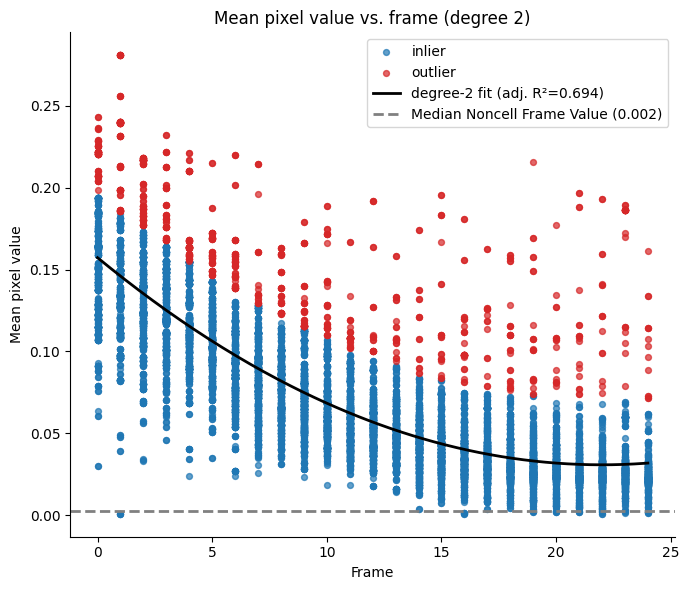

In [11]:
replicated_df = per_frame_df[per_frame_df["replicate_status"] == "replicating"].copy()

x_col = "frame"
y_col = "blob_mean_value"
DEGREE = 2

# Fit
per_frame_outlier_df = replicated_df.dropna(subset=[x_col, y_col]).copy()

# Center x before raising to powers: raw powers of a variable with a large
# offset are near-collinear and blow up the standard errors.
x_mean = per_frame_outlier_df[x_col].mean()
x_c = per_frame_outlier_df[x_col] - x_mean

X = pd.DataFrame({f"x{p}": x_c**p for p in range(1, DEGREE + 1)}, index=per_frame_outlier_df.index)
X = sm.add_constant(X)

model = sm.OLS(per_frame_outlier_df[y_col], X).fit()
print(model.summary())
r2adj = model.rsquared_adj

# Flag outliers by studentized residual
THRESH = 1.5
influence = model.get_influence()
per_frame_outlier_df["resid_student"] = influence.resid_studentized_internal
per_frame_outlier_df["is_outlier"] = per_frame_outlier_df["resid_student"] > THRESH
print(f"{per_frame_outlier_df['is_outlier'].sum()} outliers of {len(per_frame_outlier_df)} points")

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
for flag, label, color in [(False, "inlier", "tab:blue"), (True, "outlier", "tab:red")]:
    sub = per_frame_outlier_df[per_frame_outlier_df["is_outlier"] == flag]
    ax.scatter(sub[x_col], sub[y_col], c=color, s=18, alpha=0.7, label=label)

xs = np.linspace(per_frame_outlier_df[x_col].min(), per_frame_outlier_df[x_col].max(), 200)
xs_c = xs - x_mean
Xs = sm.add_constant(
    pd.DataFrame({f"x{p}": xs_c**p for p in range(1, DEGREE + 1)})
)
pred = model.get_prediction(Xs).summary_frame(alpha=0.05)

ax.plot(xs, pred["mean"], color="black", lw=2,
        label=f"degree-{DEGREE} fit (adj. R²={r2adj:.3f})")

# add a horizontal bar at mean_non_cell_frame_value
median_non_cell_frame_value = frame_metrics_df["norm_noncell_median"].mean()
ax.axhline(median_non_cell_frame_value, color="grey", linestyle="--", lw=2, label=f"Median Noncell Frame Value ({median_non_cell_frame_value:.3f})")

ax.set_xlabel("Frame")
ax.set_ylabel("Mean pixel value")
ax.set_title(f"Mean pixel value vs. frame (degree {DEGREE})")
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [12]:
filtered_df = per_frame_outlier_df.loc[
    (~per_frame_outlier_df["is_outlier"])
    & (~(per_frame_outlier_df["frame"] > 20))
].drop(columns="is_outlier")

# Build per-frame DataFrames with and without segment starts
per_frame_repl_df = build_per_frame_df(
    filtered_df, dedupe=True,
    drop_segment_starts=True,
    verbose=False,
)
per_frame_repl_with_start_df = build_per_frame_df(
    filtered_df, dedupe=True,
    drop_segment_starts=False,
    verbose=False,
)

# per lineage and per well DataFrames, without segment starts
per_lineage_repl_df = build_per_lineage_df(
    per_frame_repl_df,
    drop_segment_starts=True,
)
per_well_repl_df = build_per_well_df(per_lineage_repl_df, min_steps_per_lineage=2)

display(per_frame_repl_df.head())
display(per_lineage_repl_df.head())
display(per_well_repl_df.head())

,experiment,cell_type,well,well_row,well_col,treatment,manually_excluded,frame,frame_width,cell_id,...,is_replication_event,peak_value,blob_mean_value,n_cells_in_frame,was_ever_replication_product,will_ever_replicate,n_slots_at_position,cumulative_replications,replicate_status,resid_student
0,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,1,57,0,...,False,0.256676,0.109923,1,False,True,4,0,replicating,-1.373855
1,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,2,57,0,...,True,0.242858,0.111190,2,True,True,2,1,replicating,-0.917598
2,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,3,57,0,...,False,0.162610,0.148320,2,True,True,2,1,replicating,0.883794
3,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,4,57,0,...,False,0.153971,0.099880,2,True,True,2,1,replicating,-0.591828
4,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,5,57,0,...,False,0.150065,0.097185,2,True,True,2,1,replicating,-0.346185


,experiment,cell_type,well,well_row,well_col,treatment,manually_excluded,cell_id,segment_id,replicate_status,...,last_frame,start_row,start_col,end_row,end_col,n_replications,mean_shared_slots,net_displacement,straightness,observed_frames
0,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,0,0,replicating,...,17,25.071429,30.857143,26.0,21.0,3,1.823529,9.900783,0.079210,18
1,FL2026-3_plate1,Non-HSC,well_B10,B,10,Inhibin-A,False,12,0,replicating,...,20,44.000000,44.000000,57.0,51.0,7,13.250000,14.764823,0.068165,21
2,FL2026-2_plate1,Non-HSC,well_D1,D,1,CTRL,False,0,0,replicating,...,19,21.000000,26.000000,23.0,34.0,3,2.368421,8.246211,0.077681,20
3,FL2026-3_plate1,HSC,well_C11,C,11,Inhibin-A,False,3,0,replicating,...,20,36.000000,32.000000,47.0,24.0,5,4.315789,13.601471,0.113459,20
4,FL2026-3_plate2,Non-HSC,well_D4,D,4,CTRL,False,8,0,replicating,...,19,50.000000,61.000000,66.0,82.0,8,4.222222,26.400758,0.107240,19


,experiment,cell_type,well,well_row,well_col,treatment,manually_excluded,replicate_status,n_lineages,n_steps,step_median,step_mean,total_distance,straightness,mean_track_length
0,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,replicating,4,68,5.692582,7.295065,114.727412,0.120109,18.0
1,FL2026-2_plate1,HSC,well_B5,B,5,CTRL,False,replicating,3,39,6.403124,7.451415,95.567891,0.171619,14.0
2,FL2026-2_plate1,HSC,well_C1,C,1,CTRL,False,replicating,4,68,5.996656,6.299272,108.006498,0.103233,18.0
3,FL2026-2_plate1,HSC,well_D11,D,11,Inhibin-A,False,replicating,4,40,7.450663,8.446729,81.621405,0.231461,11.0
4,FL2026-2_plate1,HSC,well_D2,D,2,CTRL,False,replicating,3,51,3.605551,4.440740,68.732456,0.234598,18.0


# Visualizing trends for filtered data

In [13]:
per_frame_repl_df["hour"] = per_frame_repl_df["frame"] * 3
per_frame_repl_with_start_df["hour"] = per_frame_repl_with_start_df["frame"] * 3

per_frame_repl_df.head()

,experiment,cell_type,well,well_row,well_col,treatment,manually_excluded,frame,frame_width,cell_id,...,peak_value,blob_mean_value,n_cells_in_frame,was_ever_replication_product,will_ever_replicate,n_slots_at_position,cumulative_replications,replicate_status,resid_student,hour
0,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,1,57,0,...,0.256676,0.109923,1,False,True,4,0,replicating,-1.373855,3
1,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,2,57,0,...,0.242858,0.111190,2,True,True,2,1,replicating,-0.917598,6
2,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,3,57,0,...,0.162610,0.148320,2,True,True,2,1,replicating,0.883794,9
3,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,4,57,0,...,0.153971,0.099880,2,True,True,2,1,replicating,-0.591828,12
4,FL2026-2_plate1,HSC,well_B4,B,4,CTRL,False,5,57,0,...,0.150065,0.097185,2,True,True,2,1,replicating,-0.346185,15


In [14]:
TRACK = ["experiment", "cell_type", "well", "cell_id", "segment_id"]

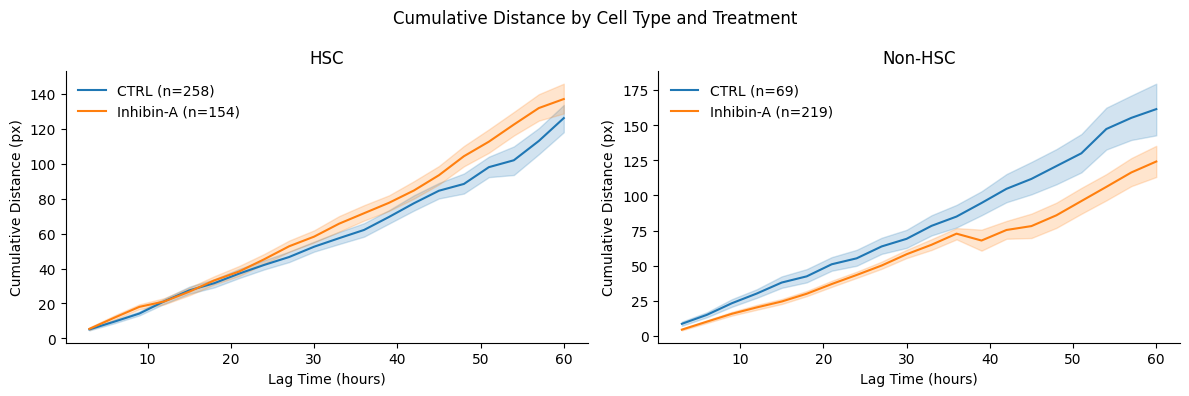

In [ ]:
n_rows = 1
n_col = per_frame_repl_df["cell_type"].nunique()

treatments = sorted(per_frame_repl_df["treatment"].unique())
color_map = dict(zip(treatments, sns.color_palette("tab10", n_colors=len(treatments))))
color_map["non-replicating"] = "grey"
condition_order = list(treatments) + ["non-replicating"]

fig, axes = plt.subplots(
    n_rows, n_col,
    figsize=(6 * n_col, 4 * n_rows),
    sharex=True,
    squeeze=False
)

for i, cell_type in enumerate(per_frame_repl_df["cell_type"].unique()):
    ax = axes[0, i]

    sub = per_frame_repl_df[
        (per_frame_repl_df["cell_type"] == cell_type)
    ].copy()

    sub["condition"] = sub["treatment"].where(
        sub["replicate_status"] == "replicating", "non-replicating"
    )

    # n = number of tracks
    counts = sub.drop_duplicates(subset=TRACK)["condition"].value_counts()
    sub["condition_n"] = sub["condition"].map(lambda c: f"{c} (n={counts.get(c, 0)})")

    # local order/palette derived from the global map
    present = [c for c in condition_order if c in counts.index]
    hue_order = [f"{c} (n={counts[c]})" for c in present]
    palette = {f"{c} (n={counts[c]})": color_map[c] for c in present}

    sns.lineplot(
        data=sub,
        x="hour",
        y="cumulative_distance",
        hue="condition_n",
        hue_order=hue_order,
        palette=palette,
        estimator=stats.gmean,
        errorbar=('ci', 95),
        ax=ax,
    )
    ax.set(
        xlabel="Lag Time (hours)",
        ylabel="Cumulative Distance (px)",
        title=f"{cell_type}",
    )
    ax.legend(title="", loc="upper left", frameon=False)
    sns.despine(ax=ax)

plt.suptitle("Cumulative Distance by Cell Type and Treatment")
plt.tight_layout()

plt.show()

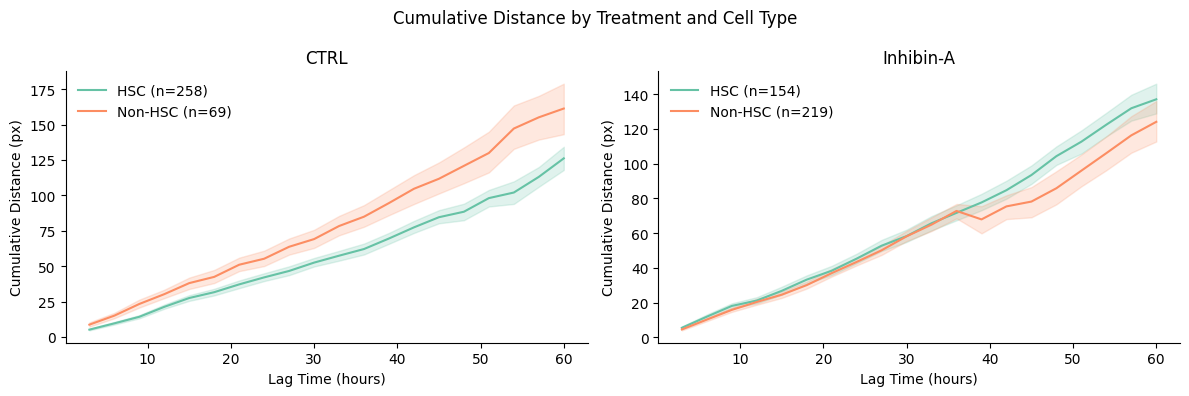

In [ ]:
n_rows = 1
n_col = per_frame_repl_df["cell_type"].nunique()

cell_types = sorted(per_frame_repl_df["cell_type"].unique())
color_map = dict(zip(cell_types, sns.color_palette("Set2", n_colors=len(cell_types))))
color_map["non-replicating"] = "grey"
condition_order = list(cell_types) + ["non-replicating"]

fig, axes = plt.subplots(
    n_rows, n_col,
    figsize=(6 * n_col, 4 * n_rows),
    sharex=True,
    squeeze=False
)

for i, treatment in enumerate(per_frame_repl_df["treatment"].unique()):
    ax = axes[0, i]

    sub = per_frame_repl_df[
        (per_frame_repl_df["treatment"] == treatment)
    ].copy()

    sub["condition"] = sub["cell_type"].where(
        sub["replicate_status"] == "replicating", "non-replicating"
    )
    # n = number of tracks
    counts = sub.drop_duplicates(subset=TRACK)["condition"].value_counts()
    sub["condition_n"] = sub["condition"].map(lambda c: f"{c} (n={counts.get(c, 0)})")

    # local order/palette derived from the global map
    present = [c for c in condition_order if c in counts.index]
    hue_order = [f"{c} (n={counts[c]})" for c in present]
    palette = {f"{c} (n={counts[c]})": color_map[c] for c in present}

    sns.lineplot(
        data=sub,
        x="hour",
        y="cumulative_distance",
        hue="condition_n",
        hue_order=hue_order,
        palette=palette,
        estimator=stats.gmean,
        errorbar=('ci', 95),
        ax=ax,
    )
    ax.set(
        xlabel="Lag Time (hours)",
        ylabel="Cumulative Distance (px)",
        title=f"{treatment}",
    )
    ax.legend(title="", loc="upper left", frameon=False)
    sns.despine(ax=ax)

plt.suptitle("Cumulative Distance by Treatment and Cell Type")
plt.tight_layout()

plt.savefig(f"{fig_dir}lineplots/fig_I_cumulative_distance_by_treatment_and_cell_type.svg", bbox_inches='tight')

plt.show()

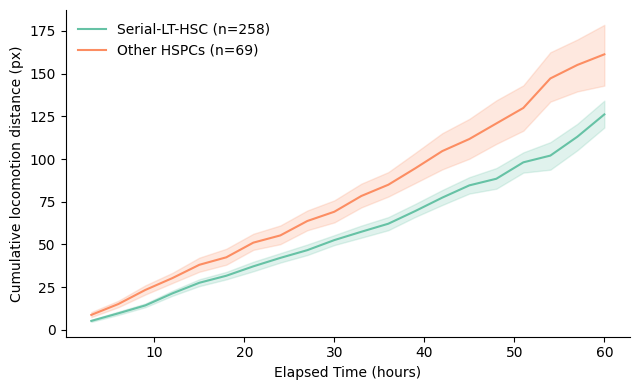

In [ ]:
display_names = {
    "Non-HSC": "Other HSPCs",
    "HSC": "Serial-LT-HSC",
}

cell_types = sorted(per_frame_repl_df["cell_type"].unique())
color_map = dict(zip(cell_types, sns.color_palette("Set2", n_colors=len(cell_types))))
color_map["non-replicating"] = "grey"
condition_order = list(cell_types) + ["non-replicating"]

# Only the left plot (first treatment)
treatment = per_frame_repl_df["treatment"].unique()[0]

fig, ax = plt.subplots(figsize=(6.5, 4))

sub = per_frame_repl_df[per_frame_repl_df["treatment"] == treatment].copy()

sub["condition"] = sub["cell_type"].where(
    sub["replicate_status"] == "replicating", "non-replicating"
)
counts = sub.drop_duplicates(subset=TRACK)["condition"].value_counts()

def label(c):
    return f"{display_names.get(c, c)} (n={counts.get(c, 0)})"

sub["condition_n"] = sub["condition"].map(label)

# local order/palette derived from the global map
present = [c for c in condition_order if c in counts.index]
hue_order = [label(c) for c in present]
palette = {label(c): color_map[c] for c in present}

sns.lineplot(
    data=sub,
    x="hour",
    y="cumulative_distance",
    hue="condition_n",
    hue_order=hue_order,
    palette=palette,
    estimator=stats.gmean,
    errorbar=("ci", 95),
    ax=ax,
)
ax.set(
    xlabel="Elapsed Time (hours)",
    ylabel="Cumulative locomotion distance (px)",
)
ax.legend(title="", loc="upper left", frameon=False)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# Cell tracking figures

In [ ]:
PALETTES = ("Blues", "Greens", "Oranges", "Purples")

# Helper functions
def _well_rows(per_frame_df, experiment, cell_type, well):
    sel = per_frame_df[
        (per_frame_df["experiment"] == experiment)
        & (per_frame_df["cell_type"] == cell_type)
        & (per_frame_df["well"] == well)
    ]
    if sel.empty:
        raise ValueError(f"no rows for {experiment}/{cell_type}/{well}")
    return sel.sort_values(["cell_id", "segment_id", "frame"]).copy()


def _cmap_for(cell_id, cell_ids, palettes, dark):
    """One palette per lineage. On black, the reversed map runs dark->light,
    so later frames get brighter instead of vanishing into the background."""
    name = palettes[list(cell_ids).index(cell_id) % len(palettes)]
    if dark and not name.endswith("_r"):
        name += "_r"
    return matplotlib.colormaps[name]


def _frame_colors(cmap, frames, norm, cmap_range):
    lo, hi = cmap_range
    return cmap(lo + (hi - lo) * norm(np.asarray(frames, dtype=float)))


def _draw_arrows(ax, x, y, colors, linewidth=2.2, arrow_scale=9.0,
                 shrink=0.0, zorder=2):
    """One arrow per frame-to-frame step, colored by the frame it leaves from.

    Zero-length steps (a cell that didn't move) are skipped: an arrow with no
    direction has no head to draw, and the dot already marks the position.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    for x0, y0, x1, y1, c in zip(x[:-1], y[:-1], x[1:], y[1:], colors):
        if np.hypot(x1 - x0, y1 - y0) < 1e-9:
            continue
        ax.add_patch(FancyArrowPatch(
            (x0, y0), (x1, y1),
            arrowstyle= "-|>, head_length=0.4, head_width=0.3", mutation_scale=arrow_scale,
            color=c, linewidth=linewidth,
            shrinkA=shrink, shrinkB=shrink, zorder=zorder,
        ))


def _draw_track(ax, x, y, frames, cmap, norm, cmap_range, arrow_per_frame,
                linewidth, arrow_scale, arrow_shrink, dot_size):
    """Either the shaded polyline (default) or per-frame dots + arrows."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    frames = np.asarray(frames, dtype=float)

    if arrow_per_frame:
        # ax.scatter(x, y, s=dot_size, linewidths=0, zorder=3,
        #            color=_frame_colors(cmap, frames, norm, cmap_range))
        if len(x) > 1:
            _draw_arrows(ax, x, y,
                         _frame_colors(cmap, frames[:-1], norm, cmap_range),
                         linewidth=linewidth, arrow_scale=arrow_scale,
                         shrink=arrow_shrink)
    elif len(x) > 1:
        pts = np.column_stack([x, y]).reshape(-1, 1, 2)
        segments = np.concatenate([pts[:-1], pts[1:]], axis=1)
        ax.add_collection(LineCollection(
            segments, linewidths=linewidth, zorder=2,
            colors=_frame_colors(cmap, frames[:-1], norm, cmap_range),
        ))


def load_well_stack(base_path, experiment, cell_type, well,
                    max_frames=None, tif_suffix=".tif"):
    """The same read the pipeline does: sorted .tif, greyscale, (T, H, W).

    Pass the same `max_frames_per_well` you ran the pipeline with, or frame
    indices in per_frame_df won't line up with the stack.
    """
    from skimage import color
    from skimage.io import imread

    directory = os.path.join(base_path, experiment, cell_type, well)
    files = sorted(f for f in os.listdir(directory) if f.endswith(tif_suffix))
    if max_frames is not None:
        files = files[:max_frames]
    if not files:
        raise FileNotFoundError(f"no '{tif_suffix}' files in {directory}")

    frames = []
    for name in files:
        img = imread(os.path.join(directory, name))
        frames.append(color.rgb2gray(img) if img.ndim == 3 else img)
    return np.stack(frames, axis=0).astype(float)


def _show_background(ax, image):
    lo, hi = float(image.min()), float(image.max())
    ax.imshow((image - lo) / (hi - lo + 1e-9), cmap="gray",
              interpolation="nearest", zorder=0)


def _style(ax, dark, image_shape, rows, pad=20):
    if image_shape is not None:
        h, w = image_shape
        ax.set_xlim(-0.5, w - 0.5)
        ax.set_ylim(h - 0.5, -0.5)
    else:
        ax.set_xlim(rows["col"].min() - pad, rows["col"].max() + pad)
        ax.set_ylim(rows["row"].max() + pad, rows["row"].min() - pad)
    ax.set_aspect("equal")
    ax.set_facecolor("black" if dark else "white")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)



def plot_well_tracks(
    per_frame_df, experiment, cell_type, treatment, well,
    palettes=PALETTES,
    cmap_range=(0, 1.0),
    linewidth=2.2,
    arrow_per_frame=False,
    arrow_scale=9.0,
    arrow_shrink=1.0,
    dot_size=14,
    dark=True,
    image_shape=None,
    show_colorbar=False,
    show_legend=False,
    figsize=(7.5, 7.5),
    ax=None,
):
    """Plot each lineage's path across all frames, one palette each, hue by frame.

    arrow_per_frame: draw a dot at each frame's position and join consecutive
    frames with arrows (direction of travel) instead of a plain shaded line.
    arrow_scale sets the head size in points; arrow_shrink pulls the arrow
    ends back so the dots stay visible.
    """
    rows = _well_rows(per_frame_df, experiment, cell_type, well)
    cell_ids = sorted(rows["cell_id"].unique())
    norm = Normalize(vmin=rows["frame"].min(), vmax=max(rows["frame"].max(), 1))

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure
    fig.patch.set_facecolor("black" if dark else "white")
    _style(ax, dark, image_shape, rows)

    for cell_id in cell_ids:
        cmap = _cmap_for(cell_id, cell_ids, palettes, dark)
        for _, seg in rows[rows["cell_id"] == cell_id].groupby("segment_id"):
            _draw_track(ax, seg["col"], seg["row"], seg["frame"], cmap, norm,
                        cmap_range, arrow_per_frame, linewidth, arrow_scale,
                        arrow_shrink, dot_size)
            first, last = seg.iloc[0], seg.iloc[-1]
            edge = cmap(cmap_range[1])
            ax.scatter(first["col"], first["row"], s=28, facecolors="none",
                       edgecolors=edge, linewidths=1.4, zorder=4)   # segment start
            if not arrow_per_frame:      # otherwise the per-frame dot covers it
                ax.scatter(last["col"], last["row"], s=30, color=edge, zorder=3)

    text_c = "white" if dark else "black"
    if show_legend:
        ax.legend(
            handles=[Line2D([0], [0], color=_cmap_for(c, cell_ids, palettes, dark)(0.75),
                            lw=3, label=f"lineage {c}") for c in cell_ids],
            loc="upper right", frameon=False, labelcolor=text_c, fontsize=8,
        )
    ax.set_title(f"{experiment} / {cell_type} / {treatment} / {well}"   , color=text_c, fontsize=10)

    if show_colorbar:
        sm = plt.cm.ScalarMappable(norm=norm, cmap="Greys_r" if dark else "Greys")
        cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
        cbar.set_label("frame", color=text_c, fontsize=8)
        cbar.ax.tick_params(colors=text_c, labelsize=7)
        cbar.outline.set_edgecolor(text_c)

    fig.tight_layout()
    return ax

def animate_well_tracks(
    per_frame_df, experiment, cell_type, treatment, well,
    show_circles=True,
    background="dark",
    base_path=None,
    max_frames=None,
    stack=None,
    palettes=PALETTES,
    cmap_range=(0, 1.0),
    circle_radius=3.0,
    trail=True,
    trail_n=1,
    linewidth=2.2,
    arrow_per_frame=False,
    arrow_scale=9.0,
    arrow_shrink=1.0,
    dot_size=14,
    show_colorbar=False,
    show_legend=False,
    figsize=(6, 6),
    fps=4,
    save_path=None,
):
    rows = _well_rows(per_frame_df, experiment, cell_type, well)
    cell_ids = sorted(rows["cell_id"].unique())
    dark = background != "image"
 
    if background == "image" and stack is None:
        if base_path is None:
            raise ValueError("background='image' needs base_path (or stack)")
        stack = load_well_stack(base_path, experiment, cell_type, well, max_frames)
 
    n_frames = len(stack) if stack is not None else int(rows["frame"].max()) + 1
    image_shape = stack.shape[1:] if stack is not None else None
    norm = Normalize(vmin=0, vmax=max(n_frames - 1, 1))
    cmaps = {c: _cmap_for(c, cell_ids, palettes, dark) for c in cell_ids}
 
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("black" if dark else "white")
    text_c = "white" if dark else "black"
 
    def draw(t):
        ax.clear()
        _style(ax, dark, image_shape, rows)
        if stack is not None:
            _show_background(ax, stack[t])
 
        # oldest frame still drawn: the whole history, the last trail_n steps,
        # or just t itself when the trail is switched off.
        if not trail:
            first_frame = t
        elif trail_n is None:
            first_frame = -np.inf
        else:
            first_frame = t - trail_n
 
        for cell_id in cell_ids:
            cmap = cmaps[cell_id]
            for _, seg in rows[rows["cell_id"] == cell_id].groupby("segment_id"):
                past = seg[(seg["frame"] <= t) & (seg["frame"] >= first_frame)]
                if past.empty:
                    continue
                _draw_track(ax, past["col"], past["row"], past["frame"],
                            cmap, norm, cmap_range, arrow_per_frame,
                            linewidth, arrow_scale, arrow_shrink, dot_size)
                here = past[past["frame"] == t]
                if len(here) and show_circles:
                    color = _frame_colors(cmap, [t], norm, cmap_range)[0]
                    for _, rec in here.iterrows():
                        ax.add_patch(Circle(
                            (rec["col"], rec["row"]), circle_radius, fill=False,
                            edgecolor=color, linewidth=1.6, zorder=5,
                        ))
 
        ax.set_title(f"{experiment} / {cell_type} / {treatment} / {well} — frame {t}",
                     color=text_c, fontsize=10)
        if show_legend:
            ax.legend(
                handles=[Line2D([0], [0], color=cmaps[c](0.75), lw=3, label=f"lineage {c}")
                         for c in cell_ids],
                loc="upper right", frameon=False, labelcolor=text_c, fontsize=8,
            )
        if show_colorbar:
            sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=norm)
            sm.set_array([])
            cbar = plt.colorbar(sm, ax=ax)
            cbar.set_label("Frame", color=text_c)
            cbar.ax.yaxis.set_tick_params(color=text_c)
            plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color=text_c)
 
        return ()
 
    anim = FuncAnimation(fig, draw, frames=n_frames,
                         interval=1000.0 / fps, blit=False, repeat=True)
    if save_path:
        anim.save(save_path, writer=PillowWriter(fps=fps))
    return anim

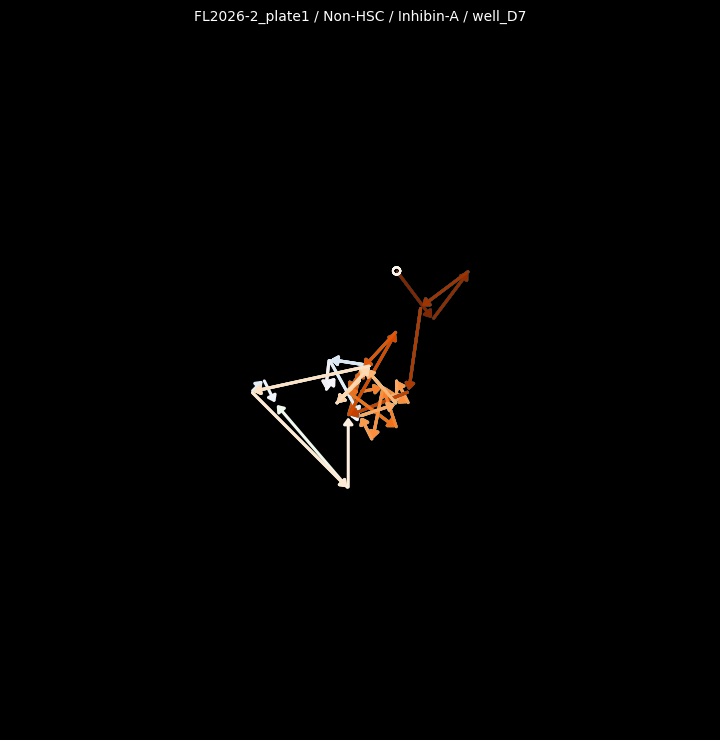

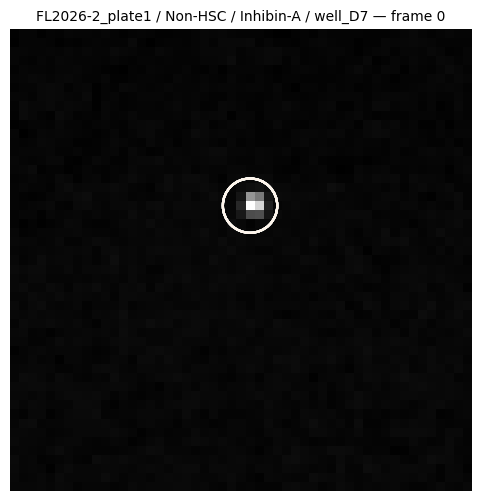

In [19]:
experiment, cell_type, treatment, well = (
    per_frame_repl_with_start_df[per_frame_repl_with_start_df["n_cells_in_frame"] == 3]
    .iloc[60][["experiment", "cell_type", "treatment", "well"]]
)
plot_well_tracks(
    per_frame_repl_with_start_df[per_frame_repl_with_start_df["frame"] <= 20],
    experiment, cell_type, treatment, well, arrow_per_frame=True
)
plt.savefig(f"{fig_dir}cell_tracks/fig1_{experiment}_{cell_type}_{treatment}_{well}.svg")
plt.show()

anim = animate_well_tracks(
    per_frame_repl_with_start_df[per_frame_repl_with_start_df["frame"] <= 20],
    experiment, cell_type, treatment, well,
    trail_n=1,
    arrow_per_frame=True,
    show_circles=True,
    background="image",
    base_path="../data/Inhibin-A experiment/",
)
HTML(anim.to_jshtml())

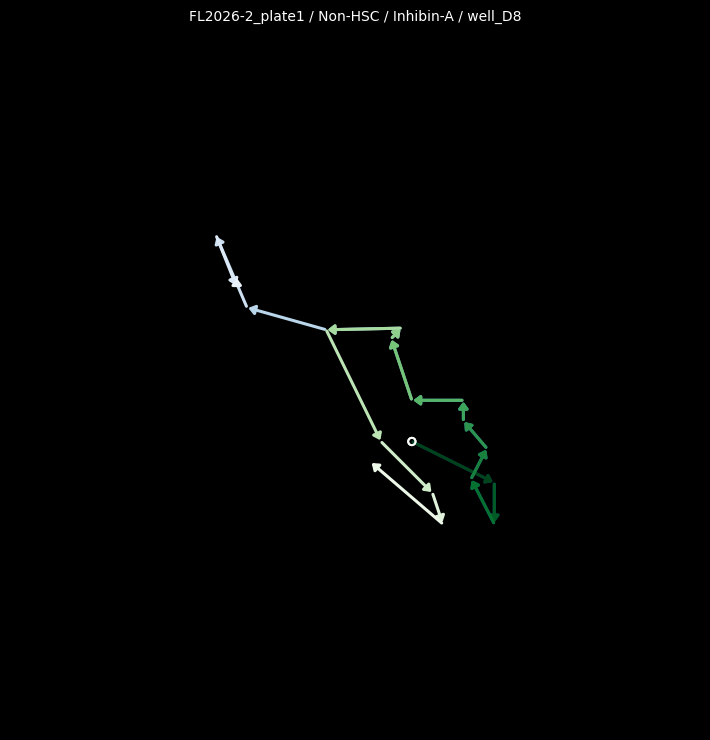

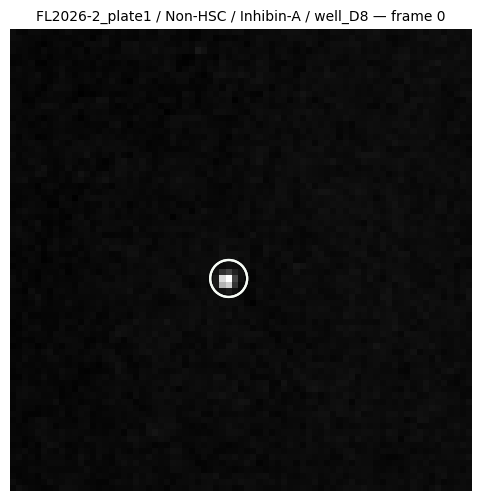

In [20]:
experiment = "FL2026-2_plate1"
cell_type = "Non-HSC"
treatment = "Inhibin-A"
well = "well_D8"

plot_well_tracks(
    per_frame_repl_with_start_df[per_frame_repl_with_start_df["frame"] <= 20],
    experiment, cell_type, treatment, well, arrow_per_frame=True
)
plt.savefig(f"{fig_dir}cell_tracks/fig2_{experiment}_{cell_type}_{treatment}_{well}.svg")
plt.show()

anim = animate_well_tracks(
    per_frame_repl_with_start_df[per_frame_repl_with_start_df["frame"] <= 20],
    experiment, cell_type, treatment, well,
    trail_n=1,
    arrow_per_frame=True,
    show_circles=True,
    background="image",
    base_path="../data/Inhibin-A experiment/",
)
HTML(anim.to_jshtml())

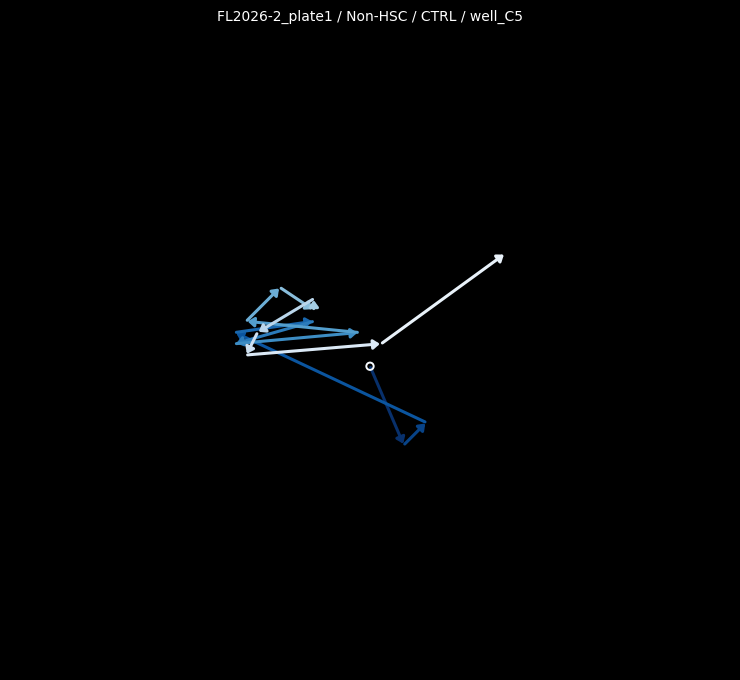

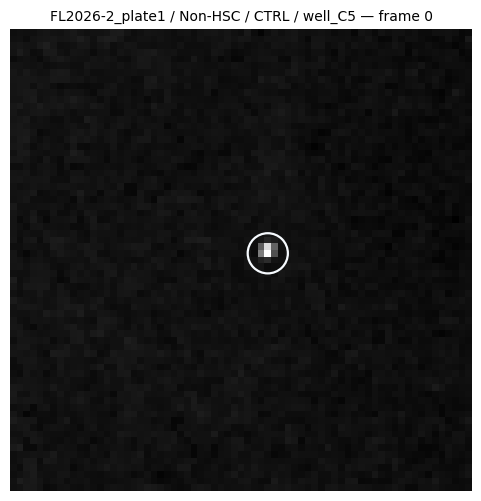

In [21]:
# need to use per_frame_df to visualize non-replicating lineages
experiment, cell_type, treatment, well = (
    per_frame_df[per_frame_df["replicate_status"] == "non-replicating"]
    .iloc[0][["experiment", "cell_type", "treatment", "well"]]
)

plot_well_tracks(
    per_frame_df[per_frame_df["frame"] <= 20],
    experiment, cell_type, treatment, well, arrow_per_frame=True
)
plt.savefig(f"{fig_dir}cell_tracks/fig3_{experiment}_{cell_type}_{treatment}_{well}.svg")
plt.show()

anim = animate_well_tracks(
    per_frame_df[per_frame_df["frame"] <= 20],
    experiment, cell_type, treatment, well,
    trail_n=1,
    arrow_per_frame=True,
    show_circles=True,
    background="image",
    base_path="../data/Inhibin-A experiment/",
)
HTML(anim.to_jshtml())

In [22]:
# # store all images for tracked cells

# for (experiment, cell_type, treatment, well), group_df in tqdm(per_frame_repl_with_start_df.groupby(
#     ["experiment", "cell_type", "treatment", "well"]
# ), desc="Saving images"):

#     plot_well_tracks(
#         group_df[group_df["frame"] <= 20],
#         experiment, cell_type, treatment, well, arrow_per_frame=True
#     )
#     plt.savefig(f"{fig_dir}all_cell_tracks/{experiment}_{cell_type}_{treatment}_{well}.svg")
#     plt.close()

In [23]:
# # store all animations for tracked cells

# for (experiment, cell_type, treatment, well), group_df in tqdm(per_frame_repl_with_start_df.groupby(
#     ["experiment", "cell_type", "treatment", "well"]
# ), desc="Processing wells"):

#     anim = animate_well_tracks(
#         group_df[group_df["frame"] <= 20],
#         experiment, cell_type, treatment, well,
#         arrow_per_frame=True,
#         trail_n=1,
#         background="image",
#         base_path="../data/Inhibin-A experiment/",
#         save_path=f"{fig_dir}all_cell_track_animations/{experiment}_{cell_type}_{treatment}_{well}.gif"
#     )
#     plt.close()